In [71]:
#%%
import math
import numpy as np

import inspect
import importlib

import scipy.interpolate
from scipy import stats
from scipy.stats import norm

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from matplotlib import ticker, cm
from matplotlib import patches as mpatches
from matplotlib.ticker import FuncFormatter
import matplotlib.lines as mlines
from matplotlib import colormaps

import seaborn as sns


plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.offline import plot
pio.renderers.default = "svg"

import sys
import os
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
#sys.path.append(os.path.dirname(parent_directory))
#sys.path.append(os.path.dirname(os.path.dirname(parent_directory)))

from IoT_node_models.Energy_model                        import *
from IoT_node_models.Energy_model.Wireless_communication import *
from IoT_node_models.Hardware_Modules                    import *
from IoT_node_models.Analysis                            import *

from fft_architecture_exploration                        import *

path_to_save_svg = "Saved_Data"


rng = np.random.default_rng(42)

In [72]:
dictColor = {"DeepBlue"     :"#095256",
             "LightBlue"    :"#01a7c2",
             "UnitedBlue"   :"#6290c8",
             "CerulBlue"    :"#6096ba",
             "Green"        :"#44af69",
             "LightRed"     :"#f8333c",
             "DeepRed"      :"#a22c29",
             "Orange"       :"#fcab10",
             "Sandy"        :"#fc9e4F",
             "Olivine"      :"#9ab87a",
             "CarolinaBlue" :"#009DDC"}
listColor = list(dictColor.values())

In [73]:

import matplotlib.colors as mcolors

# Define base colors for each row
base_colors = {
    'red': '#f8333c',      # LightRed as base
    'blue': "#64ABD4",     # DeepBlue as base  
    'green': '#44af69',    # Green as base
    'orange': '#fcab10',   # Orange as base
    'purple': '#800080'    # Standard purple as base
}

# Create 10 nuances for each color by varying lightness
color_array = np.zeros((5, 10), dtype=object)

for i, (color_name, base_hex) in enumerate(base_colors.items()):
    base_rgb = mcolors.hex2color(base_hex)
    for j in range(10):
        # Create lighter/darker variations by scaling RGB values
        # Use a non-linear scaling for better visual distribution
        scale = 0.5 + 0.5 * (j / 9) ** 0.7  # 0.5 to 1.0 with curve
        if color_name == 'purple':
            # For purple, create a nice gradient from dark to light
            lightness = j / 9.0  # 0 to 1
            if j < 5:
                # Dark to medium purples
                r = 0.5 + 0.3 * (j / 4.0)
                b = 0.5 + 0.3 * (j / 4.0)
                g = 0.0 + 0.2 * (j / 4.0)
            else:
                # Medium to light purples
                r = 0.8 + 0.2 * ((j - 5) / 4.0)
                b = 0.8 + 0.2 * ((j - 5) / 4.0)
                g = 0.4 + 0.4 * ((j - 5) / 4.0)
            color_array[i, j] = mcolors.rgb2hex((r, g, b))
        else:
            # For other colors, scale from darker to lighter
            if j < 5:
                # Darker variations (scale down)
                scaled_rgb = tuple(max(0, min(1, c * (0.4 + 0.6 * (j / 4.0)))) for c in base_rgb)
            else:
                # Lighter variations (scale up)
                scaled_rgb = tuple(max(0, min(1, c * (1.0 + 0.6 * ((j - 5) / 4.0)))) for c in base_rgb)
            color_array[i, j] = mcolors.rgb2hex(scaled_rgb)

# Rename rows for clarity
color_names = ['red', 'blue', 'green', 'orange', 'purple']

In [74]:
analysis_Mem_type  = np.array([1]) # 0: 1xSP SRAM,   1: 2xSP SRAM, 2: 2xHalf-size SP SRAM,  3: 1xDP SRAM
analysis_nMem_type = len(analysis_Mem_type)

baseline_area    = pipe_theor_Area[0,analysis_Mem_type]

baseline_techNode= 65 #10
baseline_energy  = pipe_theor_Energy[0,analysis_Mem_type]
baseline_latency = pipe_theor_Latency[0,analysis_Mem_type]
baseline_power   = baseline_energy / baseline_latency

area_overlap = 0#0.095
print(baseline_latency)

[49152.]


In [75]:
print(baseline_area)
print(baseline_energy)
print(baseline_latency/4096)

[0.195129]
[2.79568712e-06]
[12.]


In [76]:
# ----------------------------------------------------------------------
#           RATIO
# ----------------------------------------------------------------------


para_theor_Speedup        = baseline_latency        / para_theor_Latency                                
para_theor_Power          = para_theor_Energy       / para_theor_Latency
   
pipePara_theor_Speedup    = baseline_latency            / pipePara_theor_Latency                                
pipePara_theor_Power      = pipePara_theor_Energy       / pipePara_theor_Latency 

pipe_theor_Speedup        = baseline_latency        / pipe_theor_Latency                                
pipe_theor_Power          = pipe_theor_Energy       / pipe_theor_Latency

# ----------------------------------------------------------------------

theor_Area             = np.array([pipe_theor_Area         ,  para_theor_Area     ,  pipePara_theor_Area]) - area_overlap
theor_Latency          = np.array([pipe_theor_Latency      ,  para_theor_Latency  ,  pipePara_theor_Latency])
theor_Energy           = np.array([pipe_theor_Energy       ,  para_theor_Energy   ,  pipePara_theor_Energy])
theor_Speedup          = np.array([pipe_theor_Speedup      ,  para_theor_Speedup  ,  pipePara_theor_Speedup])                              
theor_Power            = np.array([pipe_theor_Power        ,  para_theor_Power    ,  pipePara_theor_Power]) 

# ----------------------------------------------------------------------

para_theor_area_ratio    = (para_theor_Area[:,:,np.newaxis] - area_overlap)    / baseline_area
para_theor_power_ratio   = para_theor_Power   / baseline_power
para_theor_energy_ratio  = para_theor_Energy  / baseline_energy
para_theor_latency_ratio = para_theor_Latency / baseline_latency
para_theor_speedup_ratio = 1/(para_theor_latency_ratio)


# ----------------------------------------------------------------------
pipe_theor_area_ratio    = (pipe_theor_Area[:,:,np.newaxis] - area_overlap)    / baseline_area
pipe_theor_power_ratio   = pipe_theor_Power   / baseline_power
pipe_theor_energy_ratio  = pipe_theor_Energy  / baseline_energy
pipe_theor_latency_ratio = pipe_theor_Latency / baseline_latency
pipe_theor_speedup_ratio = 1/(pipe_theor_latency_ratio)


# ----------------------------------------------------------------------
pipePara_theor_area_ratio    = (pipePara_theor_Area[:,:,np.newaxis] - area_overlap)    / baseline_area
pipePara_theor_power_ratio   = pipePara_theor_Power   / baseline_power
pipePara_theor_energy_ratio  = pipePara_theor_Energy  / baseline_energy
pipePara_theor_latency_ratio = pipePara_theor_Latency / baseline_latency
pipePara_theor_speedup_ratio = 1/(pipePara_theor_latency_ratio)

# ----------------------------------------------------------------------


theor_area_ratio        = np.array([pipe_theor_area_ratio       , para_theor_area_ratio    , pipePara_theor_area_ratio])  
theor_power_ratio       = np.array([pipe_theor_power_ratio      , para_theor_power_ratio   , pipePara_theor_power_ratio])
theor_energy_ratio      = np.array([pipe_theor_energy_ratio     , para_theor_energy_ratio  , pipePara_theor_energy_ratio])
theor_latency_ratio     = np.array([pipe_theor_latency_ratio    , para_theor_latency_ratio , pipePara_theor_latency_ratio])                              
theor_speedup_ratio     = np.array([pipe_theor_speedup_ratio    , para_theor_speedup_ratio , pipePara_theor_speedup_ratio]) 

In [77]:



#----------------------------------------------------------------------------------


our_Area           = np.array([0.119    , 0.123    , 0.129    , 0.141    ] ) 
our_NFFT           = np.array([4096     , 4096     , 4096     , 4096     ] )                 
our_Latency_pFFT   = np.array([98423    , 49250    , 32883    , 24723    ] )               
our_Energy_pFFT    = np.array([3388.9   , 1922.4   , 1434.1   , 1197.6    ] ) *1e-9 

baseline_area    = np.array([our_Area[0]])
our_Latency        = our_Latency_pFFT   
our_Energy         = our_Energy_pFFT       
our_Speedup        = baseline_latency / our_Latency                                
our_Power          = our_Energy       / our_Latency  

our_area_ratio    = (our_Area[:,np.newaxis])    / baseline_area
our_power_ratio   = our_Power   / baseline_power
our_energy_ratio  = our_Energy  / baseline_energy
our_latency_ratio = our_Latency / baseline_latency
our_speedup_ratio = 1/(our_latency_ratio)

#----------------------------------------------------------------------------------
soA_name          =           [ "Pereira 22" , "Berta. 21 ", "Gonz. 24",  "Yang 21", "Mahdavi 19", "Shih 18", "Shih 18", "Tian 19"  , "Paul 25"  , "Zhang 25" ,  "Liu 18"   ]         #"Deng 23"
soA_type          =           [ "Memory-b"   , "Memory-b"  , "Memory-b",  "Pipel." , "Pipel."    , "Pipel." , "Pipel." , "Memory-b" , "Memory-b" , "Memory-b" ,  "Memory-b" ]         #"Pipel." 
soA_techNode      =           [    65        , 22          , 22        ,  65       , 28          , 40       , 40       ,65          , 65         , 40         ,     65      ]         #40
soa_Area_FFT       = np.array([    0.185     , 0.185       , 1.08      ,  1.83     , 0.57        , 1.09     , 1.25     ,0.84        , 3.8        , 1.11       ,    1.67     ] )       #0.48                        
soa_NFFT           = np.array([    256       , 1024        , 1024      ,  2048     , 2048        , 2048     , 4096     ,4096        , 4096       , 4096       ,    4096     ] )       #1024                       
soa_Latency_pFFT   = np.array([    1025      , 3005        , 1320      ,  2048     , 1200        , 2048     , 4096     ,5120        , 605        , 2259       ,    768      ] )       #245                         
soa_Energy_pFFT    = np.array([    187.23    , 1054.78     , 297.92    ,  260.31   , 600.82      , 541.60   , 1658.43  ,599.04      , 495.67     , 1221.50    ,   240.98    ] ) *1e-9 #22.94      

soa_Area           = scale_area    (area= soa_Area_FFT,        nfft_ref = 4096, nfft = soa_NFFT, acc_type =soA_type)    
soa_Latency        = scale_latency (latency= soa_Latency_pFFT, nfft_ref = 4096, nfft = soa_NFFT, acc_type =soA_type)                      
soa_Energy         = soa_Energy_pFFT  * (4096*12/(soa_NFFT*np.log2(soa_NFFT)))     
 
soa_Speedup        = baseline_latency / soa_Latency                               
soa_Power          = soa_Energy       / soa_Latency  

soa_area_ratio    = (soa_Area[:,np.newaxis])    / baseline_area
soa_power_ratio   = soa_Power   / baseline_power
soa_energy_ratio  = soa_Energy  / baseline_energy
soa_latency_ratio = soa_Latency / baseline_latency
soa_speedup_ratio = 1/(soa_latency_ratio)

#----------------------------------------------------------------------------------
soA_pt_name          =           [ "Liu 18"   ]   
soA_pt_type          =           [ "Memory-b" ]   
soA_pt_techNode       =          [    65      ] 
soa_pt_Area_FFT       = np.array([   1.67     ] ) 
soa_pt_NFFT           = np.array([   4096     ] ) 
soa_pt_Latency_pFFT   = np.array([   768      ] ) 
soa_pt_Energy_pFFT    = np.array([  240.98    ] ) *1e-9

soa_pt_Area           = scale_area    (area= soa_pt_Area_FFT,        nfft_ref = 4096, nfft = soa_pt_NFFT, acc_type =soA_pt_type)    
soa_pt_Latency        = scale_latency (latency= soa_pt_Latency_pFFT, nfft_ref = 4096, nfft = soa_pt_NFFT, acc_type =soA_pt_type)                      
soa_pt_Energy         = soa_pt_Energy_pFFT  * (4096*12/(soa_pt_NFFT*np.log2(soa_pt_NFFT)))     
 
soa_pt_Speedup        = baseline_latency / soa_pt_Latency                               
soa_pt_Power          = soa_pt_Energy    / soa_pt_Latency  

soa_pt_area_ratio    = (soa_pt_Area[:,np.newaxis])    / baseline_area
soa_pt_power_ratio   = soa_pt_Power   / baseline_power
soa_pt_energy_ratio  = soa_pt_Energy  / baseline_energy
soa_pt_latency_ratio = soa_pt_Latency / baseline_latency
soa_pt_speedup_ratio = 1/(soa_pt_latency_ratio)



In [78]:
max_usable_speedup = 10


In [79]:
soa_only_last_one =True

In [80]:

alpha_studied = np.linspace(0.0001, 1, 100,endpoint=True)

# ----------------------------------------------------------------------
# 2a. DERIVE RATIOS 
# ----------------------------------------------------------------------

theor_asi_res     = np.zeros((len(alpha_studied),len(baseline_area),3,arch_Dim,analysis_nMem_type))
theor_ncf_res     = np.zeros((len(alpha_studied),len(baseline_area),3,arch_Dim,analysis_nMem_type,3))
theor_crit_alpha  = np.zeros((len(baseline_area),3,arch_Dim,analysis_nMem_type,2))
theor_integ_alpha = np.zeros((len(baseline_area),3,arch_Dim,analysis_nMem_type,2))
theor_count_class = np.zeros((len(baseline_area),3,arch_Dim,analysis_nMem_type,3))
for k in range(3):
    for a in range(len(baseline_area)):
        for i in range(arch_Dim):
            for d, j in enumerate(analysis_Mem_type):
                theor_asi_res[:,a,k,i,d]  = asi_function (alpha=alpha_studied, area_ratio=theor_area_ratio[k,i,j,a], power_ratio=theor_power_ratio[k,i,j],print=False)
                theor_ncf_res[:,a,k,i,d,0]= (theor_area_ratio[k,i,j,a]* (alpha_studied)) +  (theor_energy_ratio[k,i,j]* (1-alpha_studied))
                theor_ncf_res[:,a,k,i,d,1]= (theor_area_ratio[k,i,j,a]* (alpha_studied)) +  (theor_power_ratio [k,i,j]* (1-alpha_studied))
                theor_ncf_res[:,a,k,i,d,2]= (theor_area_ratio[k,i,j,a]* (alpha_studied)) +  (theor_energy_ratio[k,i,j]* (1-alpha_studied)) *min(max_usable_speedup,theor_speedup_ratio[k,i,j])
               
                theor_count_class [a,k,i,d,:] = asi_class_count(theor_asi_res[:,a,k,i,d],theor_speedup_ratio[k,i,j])
                theor_crit_alpha [a,k,i,d,:]  = calc_critical_alphas(theor_area_ratio[k,i,j,a],theor_power_ratio[k,i,j],theor_energy_ratio[k,i,j])
                theor_integ_alpha[a,k,i,d,:]  = integ_alphas        (theor_area_ratio[k,i,j,a],theor_power_ratio[k,i,j],theor_energy_ratio[k,i,j])
                print(f"THEOR {k},{a},{j},{i}: area_ratio={theor_area_ratio[k,i,j,a]:.2f}, area={theor_Area[k,i,j]:.4f},  power_ratio={theor_power_ratio[k,i,j]:.2f}, energy_ratio={theor_energy_ratio[k,i,j]:.2f}, speedup={theor_speedup_ratio[k,i,j]:.2e}, Crit_alphas: FW={theor_crit_alpha[a,k,i,d,0]:.2f}, FT={theor_crit_alpha[a,k,i,d,1]:.2f}, Integ Alphas: FW={theor_integ_alpha[a,k,i,d,0]:.2f}, FT={theor_integ_alpha[a,k,i,d,1]:.2f}, Class:{theor_count_class [a,k,i,d,:]}")


theor_ncf_test     = np.zeros((len(alpha_studied),len(baseline_area),3,arch_Dim,analysis_nMem_type,2))
for k in range(3):
    for a in range(len(baseline_area)):
        for i in range(arch_Dim):
            for d, j in enumerate(analysis_Mem_type):
                theor_ncf_test[:,a,k,i,d,0]= (1 - (theor_area_ratio[k,i,j,a]* (alpha_studied)) ) /  (theor_energy_ratio[k,i,j]* (1-alpha_studied))
                theor_ncf_test[:,a,k,i,d,1]= (1 - (theor_area_ratio[k,i,j,a]* (alpha_studied)) ) /  (theor_energy_ratio[k,i,j]* (1-alpha_studied) *min(max_usable_speedup,theor_speedup_ratio[k,i,j])) 
               
          
# ----------------------------------------------------------------------

our_asi_res    = np.zeros((len(alpha_studied),len(baseline_area),len(our_area_ratio)))
our_ncf_res    = np.zeros((len(alpha_studied),len(baseline_area),len(our_area_ratio),3))
our_crit_alpha = np.zeros((len(baseline_area),len(our_area_ratio),2))
our_integ_alpha= np.zeros((len(baseline_area),len(our_area_ratio),2))
our_count_class= np.zeros((len(baseline_area),len(our_area_ratio),3))
for i in range(our_area_ratio.shape[0]):
    for a in range(len(baseline_area)):
        our_asi_res[:,a,i]  = asi_function (alpha=alpha_studied, area_ratio=our_area_ratio[i,a], power_ratio=our_power_ratio[i],print=False)
        our_ncf_res[:,a,i,0]= (our_area_ratio[i,a]* (alpha_studied)) +  (our_energy_ratio[i]* (1-alpha_studied))
        our_ncf_res[:,a,i,1]= (our_area_ratio[i,a]* (alpha_studied)) +  (our_power_ratio[i] * (1-alpha_studied))
        our_ncf_res[:,a,i,2]= (our_area_ratio[i,a]* (alpha_studied)) +  (our_energy_ratio[i]* (1-alpha_studied))*min(max_usable_speedup,our_speedup_ratio[i])

        our_count_class[a,i,:] = asi_class_count(our_asi_res[:,a,i],our_speedup_ratio[i])
        our_crit_alpha [a,i,:] = calc_critical_alphas(our_area_ratio[i,a],our_power_ratio[i],our_energy_ratio[i])
        our_integ_alpha[a,i,:] = integ_alphas        (our_area_ratio[i,a],our_power_ratio[i],our_energy_ratio[i])
        print(f"OUR {i},{a}      : area_ratio={our_area_ratio[i,a]:.2f}, area={our_Area[i]:.4f},  power_ratio={our_power_ratio[i]:.2f}, energy_ratio={our_energy_ratio[i]:.2f}, speedup={our_speedup_ratio[i]:.2e}, Crit_alphas: FW={our_crit_alpha[a,i,0]:.2f}, FT={our_crit_alpha[a,i,1]:.2f}, Integ Alphas: FW={our_integ_alpha[a,i,0]:.2f}, FT={our_integ_alpha[a,i,1]:.2f}, Class:{our_count_class [a,i,:]}")
        

# ----------------------------------------------------------------------

soa_asi_res    = np.zeros((len(alpha_studied),len(baseline_area),len(soa_area_ratio)))
soa_ncf_res    = np.zeros((len(alpha_studied),len(baseline_area),len(soa_area_ratio),3))
soa_crit_alpha = np.zeros((len(baseline_area),len(soa_area_ratio),2))
soa_integ_alpha= np.zeros((len(baseline_area),len(soa_area_ratio),2))
soa_count_class= np.zeros((len(baseline_area),len(soa_area_ratio),3))
for i in range(soa_area_ratio.shape[0]):
    for a in range(len(baseline_area)):
        soa_asi_res[:,a,i]  = asi_function (alpha=alpha_studied, area_ratio=soa_area_ratio[i,a], power_ratio=soa_power_ratio[i],print=False)
        soa_ncf_res[:,a,i,0]= (soa_area_ratio[i,a]* (alpha_studied)) +  (soa_energy_ratio[i]* (1-alpha_studied))
        soa_ncf_res[:,a,i,1]= (soa_area_ratio[i,a]* (alpha_studied)) +  (soa_power_ratio[i] * (1-alpha_studied))
        soa_ncf_res[:,a,i,2]= (soa_area_ratio[i,a]* (alpha_studied)) +  (soa_energy_ratio[i]* (1-alpha_studied))*min(max_usable_speedup,soa_speedup_ratio[i])
        
        soa_count_class[a,i,:] = asi_class_count(soa_asi_res[:,a,i],soa_speedup_ratio[i])
        soa_crit_alpha [a,i,:] = calc_critical_alphas(soa_area_ratio[i,a],soa_power_ratio[i],soa_energy_ratio[i])
        soa_integ_alpha[a,i,:] = integ_alphas        (soa_area_ratio[i,a],soa_power_ratio[i],soa_energy_ratio[i])
        print(f"SOA {i},{a}      : area_ratio={soa_area_ratio[i,a]:.2f}, area={soa_Area[i]:.4f},  power_ratio={soa_power_ratio[i]:.2f}, energy_ratio={soa_energy_ratio[i]:.2f}, speedup={soa_speedup_ratio[i]:.2e}, Crit_alphas: FW={soa_crit_alpha[a,i,0]:.2f}, FT={soa_crit_alpha[a,i,1]:.2f}, Integ Alphas: FW={soa_integ_alpha[a,i,0]:.2f}, FT={soa_integ_alpha[a,i,1]:.2f}, Class:{soa_count_class [a,i,:]}")
                
        

THEOR 0,0,1,0: area_ratio=1.00, area=0.1951,  power_ratio=1.00, energy_ratio=1.00, speedup=1.00e+00, Crit_alphas: FW=nan, FT=nan, Integ Alphas: FW=1.00, FT=1.00, Class:[0.   0.01 0.99]
THEOR 0,0,1,1: area_ratio=1.03, area=0.2013,  power_ratio=1.14, energy_ratio=0.57, speedup=2.00e+00, Crit_alphas: FW=0.93, FT=1.29, Integ Alphas: FW=0.80, FT=1.09, Class:[0.   0.93 0.07]
THEOR 0,0,1,2: area_ratio=1.06, area=0.2074,  power_ratio=1.28, energy_ratio=0.43, speedup=3.00e+00, Crit_alphas: FW=0.90, FT=1.29, Integ Alphas: FW=0.74, FT=1.17, Class:[0.  0.9 0.1]
THEOR 0,0,1,3: area_ratio=1.09, area=0.2135,  power_ratio=1.42, energy_ratio=0.36, speedup=4.00e+00, Crit_alphas: FW=0.87, FT=1.29, Integ Alphas: FW=0.72, FT=1.26, Class:[0.   0.87 0.13]
THEOR 0,0,1,4: area_ratio=1.13, area=0.2196,  power_ratio=1.56, energy_ratio=0.31, speedup=5.00e+00, Crit_alphas: FW=0.85, FT=1.29, Integ Alphas: FW=0.72, FT=1.34, Class:[0.   0.84 0.16]
THEOR 1,0,1,0: area_ratio=1.00, area=0.1951,  power_ratio=1.00, energy

d:\Pol\Documents\Research\Git_Iot_node_modeling\Test_new_applications\fft_architecture_exploration.py:28: RuntimeWarning: invalid value encountered in divide
  return (1- (alpha * area_ratio))/( (1 - alpha) * power_ratio)
d:\Pol\Documents\Research\Git_Iot_node_modeling\Test_new_applications\fft_architecture_exploration.py:33: RuntimeWarning: invalid value encountered in scalar divide
  alpha_crit_nfw = (1-energy_ratio)/(area_ratio-energy_ratio)
d:\Pol\Documents\Research\Git_Iot_node_modeling\Test_new_applications\fft_architecture_exploration.py:34: RuntimeWarning: invalid value encountered in scalar divide
  alpha_crit_nft = (1-power_ratio)/(area_ratio-power_ratio)
d:\Pol\Documents\Research\Git_Iot_node_modeling\Test_new_applications\fft_architecture_exploration.py:28: RuntimeWarning: divide by zero encountered in divide
  return (1- (alpha * area_ratio))/( (1 - alpha) * power_ratio)
C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_33808\35139615.py:32: RuntimeWarning: invalid value e

Text(0.5, 1.0, 'State-of-the-art KPIs\n')

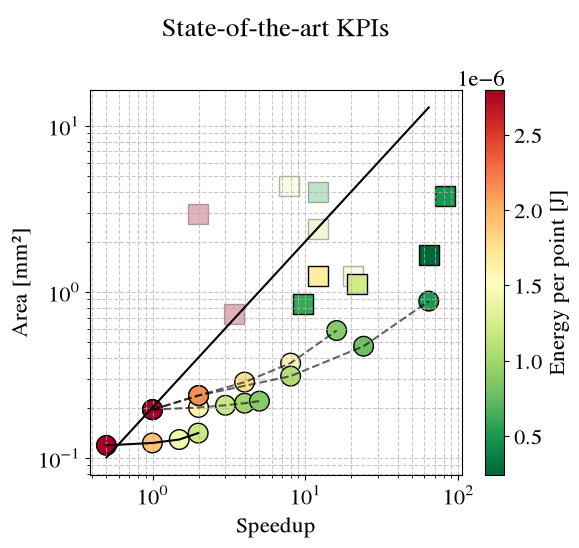

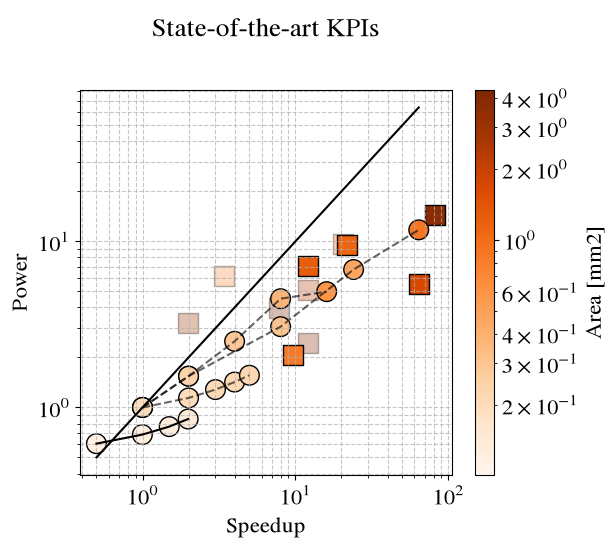

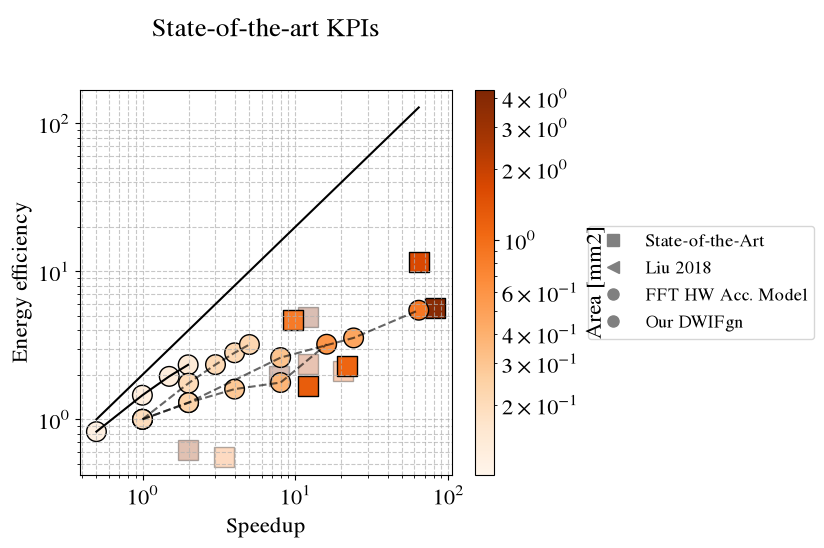

In [81]:
alpha_not_fft_size   = 0.3
plot_scaled_fft_size = 1

markersize = 200

soa_patch      = mlines.Line2D([], [], color='gray', marker="s", markersize=8, linewidth=0, label='State-of-the-Art')
soa_pt_patch   = mlines.Line2D([], [], color='gray', marker="<", markersize=8, linewidth=0, label='Liu 2018')
model_patch    = mlines.Line2D([], [], color='gray', marker="o", markersize=8, linewidth=0, label='FFT HW Acc. Model')
our_patch      = mlines.Line2D([], [], color='gray', marker="o", markersize=8, linewidth=0, label='Our DWIFgn')

fig, ax = plt.subplots(1,1, figsize=(6, 5))


ax.plot([np.min(theor_Speedup) , np.max(soa_pt_speedup_ratio)]   , [np.min(theor_Area), np.min(theor_Area)/np.min(theor_speedup_ratio) * np.max(soa_pt_speedup_ratio)]   , color = "black")    
ax.plot(our_Speedup    , our_Area  , color = "black")
sc = ax.scatter(soa_pt_Speedup, soa_pt_Area, s=markersize , c= soa_pt_Energy,  cmap='RdYlGn_r', vmin =np.min(soa_Energy)   ,vmax = np.max(pipe_theor_Energy),  marker = '<', edgecolors="black",label="Liu 2018"        ,alpha=1               )  #s=soa_pt_Power*4e12
sc = ax.scatter(our_Speedup   , our_Area   , s=markersize , c= our_Energy   ,  cmap='RdYlGn_r', vmin =np.min(soa_Energy)   ,vmax = np.max(pipe_theor_Energy),  marker = 'o', edgecolors="black",label="Our Approach"    ,alpha=1              )  #s=our_Power*4e12   

for i in range(len(soA_techNode)):
    if soa_NFFT[i] == nFFT:
        sc = ax.scatter(soa_Speedup[i]  , soa_Area[i]   , s=markersize , c= soa_Energy[i]   ,  cmap='RdYlGn_r', vmin =np.min(soa_Energy)   ,vmax = np.max(pipe_theor_Energy),  marker = 's', edgecolors="black",label="State-of-the-Art",alpha = 1)  #s=soa_Power*4e12   
    elif (plot_scaled_fft_size==1): 
        sc = ax.scatter(soa_Speedup[i]  , soa_Area[i]   , s=markersize , c= soa_Energy[i]   ,  cmap='RdYlGn_r', vmin =np.min(soa_Energy)   ,vmax = np.max(pipe_theor_Energy),  marker = 's', edgecolors="black",label="State-of-the-Art",alpha = alpha_not_fft_size)  #s=soa_Power*4e12   


for d, i in enumerate(analysis_Mem_type):
    for j in range(3):
        ax.plot(theor_Speedup[j,:,i], theor_Area[j,:,i], color = 'black', alpha=0.6, linestyle ='--')
        sc = ax.scatter(    theor_Speedup[j,:,i],     theor_Area[j,:,i], s=markersize , c=     theor_Energy[j,:,i],  cmap='RdYlGn_r', vmin =np.min(soa_Energy),vmax = np.max(theor_Energy), alpha=1, marker = 'o', edgecolors="black") #  s=    theor_Power[j,:,i]*4e12

fig.colorbar(sc, ax=ax, label='Energy per point [J]', location='right')

#ax.legend()
#ax.legend(handles=[soa_patch, soa_pt_patch, model_patch, our_patch],fontsize = 13)

ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_ylabel('Area [mm²]')
ax.set_xlabel('Speedup')
ax.set_title('State-of-the-art KPIs\n')

######################################################################################################################
fig, ax = plt.subplots(1,1, figsize=(6, 5))

normArea = colors.LogNorm(vmin=theor_Area.min(), vmax=soa_Area.max())

ax.plot([np.min(theor_Speedup) , np.max(soa_pt_speedup_ratio)]   , [np.min(theor_power_ratio), np.min(theor_power_ratio)/np.min(theor_Speedup) * np.max(soa_pt_speedup_ratio)]   , color = "black")    
ax.plot(our_Speedup    , our_power_ratio  , color = "black")        
sc = ax.scatter(soa_pt_Speedup, soa_pt_power_ratio, s=markersize , c= soa_pt_Area,  norm=normArea, cmap='Oranges', marker = '<', edgecolors="black",label="Liu 2018"                                ) # s=soa_pt_Area*2e3
sc = ax.scatter(our_Speedup   , our_power_ratio   , s=markersize , c= our_Area   ,  norm=normArea, cmap='Oranges', marker = 'o', edgecolors="black",label="Our Approach"                            ) # s=our_Area*2e3   

for i in range(len(soA_techNode)):
    if soa_NFFT[i] == nFFT:
        sc = ax.scatter(soa_Speedup[i]   , soa_power_ratio [i]  , s=markersize , c= soa_Area[i]   ,  norm=normArea, cmap='Oranges', marker = 's', edgecolors="black",label="State-of-the-Art", alpha = 1) # s=soa_Area*2e3   
    elif (plot_scaled_fft_size==1): 
        sc = ax.scatter(soa_Speedup[i]   , soa_power_ratio[i]   , s=markersize , c= soa_Area[i]   ,  norm=normArea, cmap='Oranges', marker = 's', edgecolors="black",label="State-of-the-Art", alpha =  alpha_not_fft_size)  #s=soa_Power*4e12   

for i in analysis_Mem_type:
    for j in range(3):
        ax.plot(theor_Speedup[j,:,i], theor_power_ratio[j,:,i], color = 'black', alpha=0.6, linestyle ='--')
        sc = ax.scatter(    theor_Speedup[j,:,i],     theor_power_ratio[j,:,i], s=markersize , c=     theor_Area[j,:,i],  norm=normArea, cmap='Oranges', alpha=1, marker = 'o', edgecolors="black") # s=    theor_Area[j,:,i]*2e3

fig.colorbar(sc, ax=ax, label='Area [mm2]', location='right')

#ax.legend()
#ax.legend(handles=[soa_patch, soa_pt_patch, model_patch, our_patch],fontsize = 13)

ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_ylabel('Power')
ax.set_xlabel('Speedup')
ax.set_title('State-of-the-art KPIs\n')


######################################################################################################################
fig, ax = plt.subplots(1,1, figsize=(6, 5))

ax.plot([np.min(theor_speedup_ratio) , np.max(soa_pt_speedup_ratio)]   , [np.min(1/theor_energy_ratio), np.min(1/theor_energy_ratio)/np.min(theor_speedup_ratio) * np.max(soa_pt_speedup_ratio)]   , color = "black")    
ax.plot(our_Speedup    , 1/our_energy_ratio  , color = "black")
sc = ax.scatter(soa_pt_Speedup, 1/soa_pt_energy_ratio, s = markersize , c= soa_pt_Area ,norm=normArea,  cmap='Oranges',  marker = '<', edgecolors="black", label="Liu 2018"                                ) #s=soa_pt_Area*2e3
sc = ax.scatter(our_Speedup   , 1/our_energy_ratio   , s = markersize , c= our_Area    ,norm=normArea,  cmap='Oranges',  marker = 'o', edgecolors="black", label="Our Approach"                            ) #s=our_Area*2e3   

for i in range(len(soA_techNode)):
    if soa_NFFT[i] == nFFT:
        sc = ax.scatter(soa_Speedup[i]   , 1/soa_energy_ratio[i]   , s = markersize , c= soa_Area[i]    ,norm=normArea,  cmap='Oranges',  marker = 's', edgecolors="black", label="State-of-the-Art", alpha = 1) #s=soa_Area*2e3   
    elif (plot_scaled_fft_size==1): 
       sc = ax.scatter(soa_Speedup[i]   , 1/soa_energy_ratio[i]   , s = markersize , c= soa_Area[i]    ,norm=normArea,  cmap='Oranges',  marker = 's', edgecolors="black", label="State-of-the-Art", alpha = alpha_not_fft_size) #s=soa_Area*2e3   

for i in analysis_Mem_type:
    for j in range(3):
        ax.plot(theor_Speedup[j,:,i], 1/theor_energy_ratio[j,:,i], color = 'black', alpha=0.6, linestyle ='--')
        sc = ax.scatter(    theor_Speedup[j,:,i],     1/theor_energy_ratio[j,:,i], s = markersize ,norm=normArea, c=     theor_Area[j,:,i],  cmap='Oranges',   alpha=1, marker = 'o', edgecolors="black") # s=    theor_Area[j,:,i]*2e3
        
fig.colorbar(sc, ax=ax, label='Area [mm2]', location='right')


#ax.legend()
ax.legend(handles=[soa_patch, soa_pt_patch, model_patch, our_patch],fontsize = 13, loc='right', bbox_to_anchor=(2,0.5) )
ax.set_yscale('log')
ax.set_xscale('log')
ax.grid(True, which='both', linestyle='--', alpha=0.7)
ax.set_ylabel('Energy efficiency')
ax.set_xlabel('Speedup')
ax.set_title('State-of-the-art KPIs\n')

C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_33808\4249479766.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[a,0].legend()


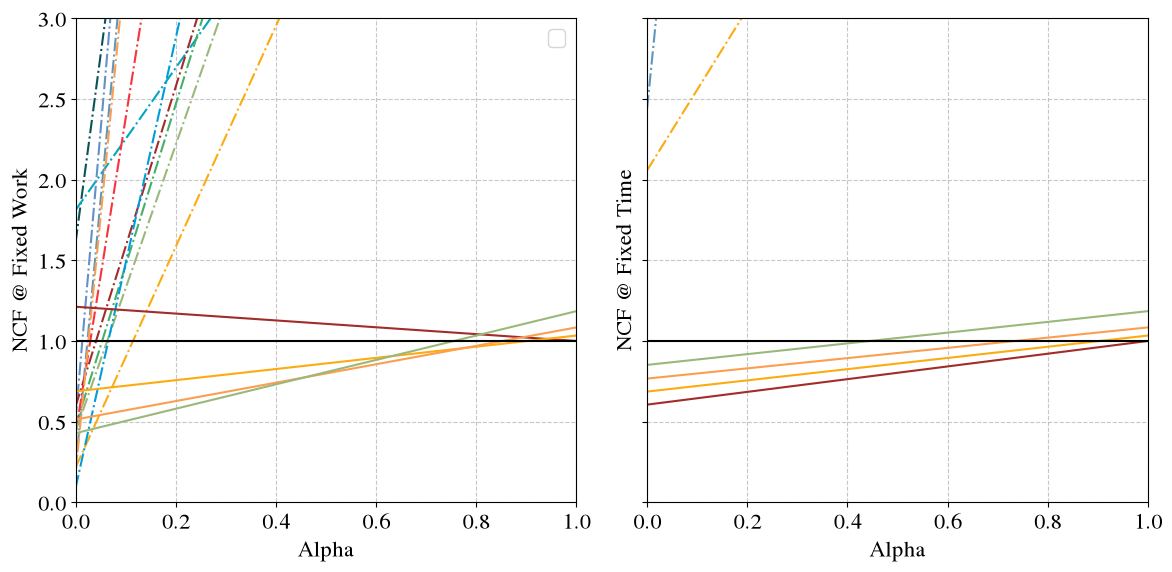

In [82]:
plot_soa   = 1
plot_our   = 1
plot_theor = 0

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(len(baseline_area),2,figsize=(12*len(baseline_area), 6), sharey='row', squeeze=False)

for a in range(len(baseline_area)):
    ax[a,0].set_xlabel('ALpha')
    ax[a,1].set_xlabel('ALpha')

    ax[a,0].grid(True, which='both', linestyle='--', alpha=0.7)
    ax[a,1].grid(True, which='both', linestyle='--', alpha=0.7)

    # Add our accelerator
    if plot_theor:
        for k in range(3):
            for d, j in enumerate(analysis_Mem_type):
                p = ax[a,0].plot(alpha_studied,   theor_ncf_res[:,a,k,0,d,0],   color = 'black' , linestyle ='-')
                p = ax[a,1].plot(alpha_studied,   theor_ncf_res[:,a,k,0,d,1],   color = 'black' , linestyle ='-')
            for i in range(1,arch_Dim):
                for d, j in enumerate(analysis_Mem_type):
                    p = ax[a,0].plot(alpha_studied,   theor_ncf_res[:,a,k,i,d,0],   color = color_array[k,i] , linestyle ='-')
                    p = ax[a,1].plot(alpha_studied,   theor_ncf_res[:,a,k,i,d,1],   color = color_array[k,i] , linestyle ='-')

    if plot_soa:
        for i in range(soa_area_ratio.shape[0]):
            p = ax[a,0].plot(alpha_studied,   soa_ncf_res[:,a,i,0],   color = listColor[i] , linestyle ='-.')
            p = ax[a,1].plot(alpha_studied,   soa_ncf_res[:,a,i,1],   color = listColor[i] , linestyle ='-.')

    if plot_our:
        for i in range(our_area_ratio.shape[0]):
            p = ax[a,0].plot(alpha_studied,   our_ncf_res[:,a,i,0],   color = listColor[i+6] , linestyle ='-')
            p = ax[a,1].plot(alpha_studied,   our_ncf_res[:,a,i,1],   color = listColor[i+6] , linestyle ='-')

    ax[a,0].hlines(y=1,xmin = 0, xmax=1, color= "black")
    ax[a,1].hlines(y=1,xmin = 0, xmax=1, color= "black")
    ax[a,0].set_ylim([0,3])
    ax[a,1].set_ylim([0,3])
    ax[a,0].set_xlim([0,1])
    ax[a,1].set_xlim([0,1])
    ax[a,0].set_xlabel("Alpha")
    ax[a,1].set_xlabel("Alpha")
    ax[a,0].set_ylabel("NCF @ Fixed Work")
    ax[a,1].set_ylabel("NCF @ Fixed Time")
    ax[a,0].legend()

# Add legend
fig.tight_layout()
plt.show()



C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_33808\4101616731.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0,0].legend()


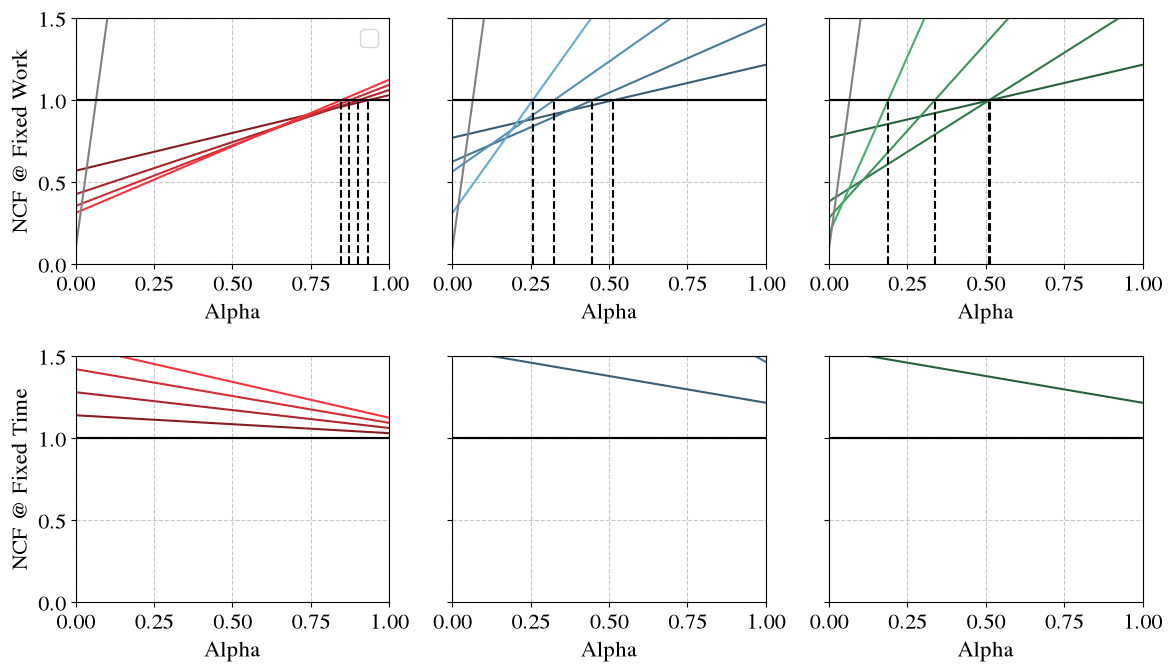

In [83]:
plot_soa = 1
plot_our = 0

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(2,3,figsize=(12, 7), sharey='row', squeeze=False)

for k in range(3):
    ax[0,k].set_xlabel('ALpha')
    ax[1,k].set_xlabel('ALpha')
    ax[0,k].grid(True, which='both', linestyle='--', alpha=0.7)
    ax[1,k].grid(True, which='both', linestyle='--', alpha=0.7)

    # Add our accelerator

    for a in range(len(baseline_area)):
        for d, j in enumerate(analysis_Mem_type):
            p = ax[0,k].plot(alpha_studied,   theor_ncf_res[:,a,k,0,d,0],   color = 'black' , linestyle ='-')
            p = ax[1,k].plot(alpha_studied,   theor_ncf_res[:,a,k,0,d,1],   color = 'black' , linestyle ='-')
            p = ax[0,k].vlines(theor_crit_alpha [a,k,0,d,0], ymin=0, ymax=1,   color = 'black' , linestyle ='--')
            p = ax[1,k].vlines(theor_crit_alpha [a,k,0,d,1], ymin=0, ymax=1,   color = 'black' , linestyle ='--')

        for i in range(1,arch_Dim):
            for d, j in enumerate(analysis_Mem_type):
                p = ax[0,k].plot(alpha_studied,   theor_ncf_res[:,a,k,i,d,0],   color = color_array[k,i] , linestyle ='-')
                p = ax[1,k].plot(alpha_studied,   theor_ncf_res[:,a,k,i,d,1],   color = color_array[k,i] , linestyle ='-')
                p = ax[0,k].vlines(theor_crit_alpha [a,k,i,d,0], ymin=0, ymax=1,   color = 'black' , linestyle ='--')
                p = ax[1,k].vlines(theor_crit_alpha [a,k,i,d,1], ymin=0, ymax=1,   color = 'black' , linestyle ='--')

        if plot_soa:
            if soa_only_last_one : 
                p = ax[0,k].plot(alpha_studied,   soa_ncf_res[:,a,-1,0],   color = 'gray', linestyle ='-')
                p = ax[1,k].plot(alpha_studied,   soa_ncf_res[:,a,-1,1],   color = 'gray', linestyle ='-')
            else:
                for i in range(soa_area_ratio.shape[0]):
                    p = ax[0,k].plot(alpha_studied,   soa_ncf_res[:,a,i,0],   color = listColor[i] , linestyle ='-.')
                    p = ax[1,k].plot(alpha_studied,   soa_ncf_res[:,a,i,1],   color = listColor[i] , linestyle ='-.')

        if plot_our:
            for i in range(our_area_ratio.shape[0]):
                p = ax[0,k].plot(alpha_studied,   our_ncf_res[:,a,i,0],   color = listColor[i+6] , linestyle ='--')
                p = ax[1,k].plot(alpha_studied,   our_ncf_res[:,a,i,1],   color = listColor[i+6] , linestyle ='--')

    ax[0,k].hlines(y=1,xmin = 0, xmax=1, color= "black")
    ax[1,k].hlines(y=1,xmin = 0, xmax=1, color= "black")
    ax[0,k].set_ylim([0,1.5])
    ax[1,k].set_ylim([0,1.5])
    ax[0,k].set_xlim([0,1])
    ax[1,k].set_xlim([0,1])
    ax[0,k].set_xlabel("Alpha")
    ax[1,k].set_xlabel("Alpha")

ax[0,0].set_ylabel("NCF @ Fixed Work")
ax[1,0].set_ylabel("NCF @ Fixed Time")
ax[0,0].legend()

# Add legend
fig.tight_layout()
plt.show()



C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_33808\2264551679.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0,0].legend()


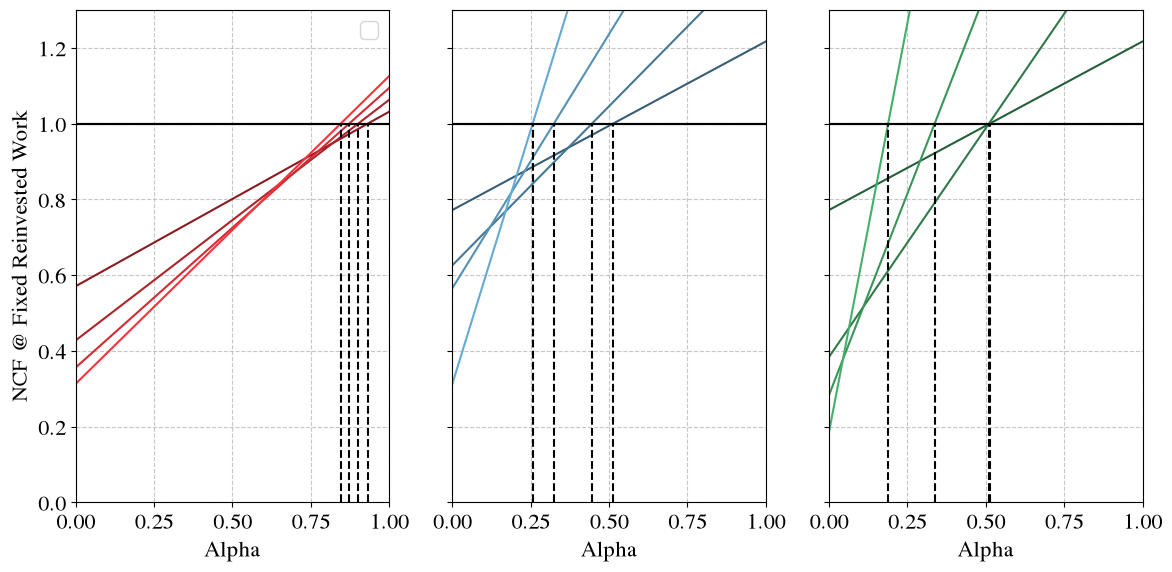

In [84]:
plot_soa = 1
plot_our = 0

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,3,figsize=(12, 6), sharey='row', squeeze=False)

for k in range(3):
    ax[0,k].set_xlabel('ALpha')
    ax[0,k].grid(True, which='both', linestyle='--', alpha=0.7)

    # Add our accelerator

    for a in range(len(baseline_area)):
        for d, j in enumerate(analysis_Mem_type):
            p = ax[0,k].plot(alpha_studied,   theor_ncf_res[:,a,k,0,d,0],   color = 'black' , linestyle ='-')
            p = ax[0,k].vlines(theor_crit_alpha [a,k,0,d,0], ymin=0, ymax=1,   color = 'black' , linestyle ='--')

        for i in range(1,arch_Dim):
            for d, j in enumerate(analysis_Mem_type):
                p = ax[0,k].plot(alpha_studied,   theor_ncf_res[:,a,k,i,d,0],   color = color_array[k,i] , linestyle ='-')
                p = ax[0,k].vlines(theor_crit_alpha [a,k,i,d,0], ymin=0, ymax=1,   color = 'black' , linestyle ='--')


    ax[0,k].hlines(y=1,xmin = 0, xmax=1, color= "black")
    ax[0,k].set_ylim([0,1.3])
    ax[0,k].set_xlim([0,1])
    ax[0,k].set_xlabel("Alpha")
    
    ax[0,k].set_xscale("linear")


ax[0,0].set_ylabel("NCF @ Fixed Reinvested Work")
ax[0,0].legend()

# Add legend
fig.tight_layout()
plt.show()



C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_33808\449775102.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0,0].legend()


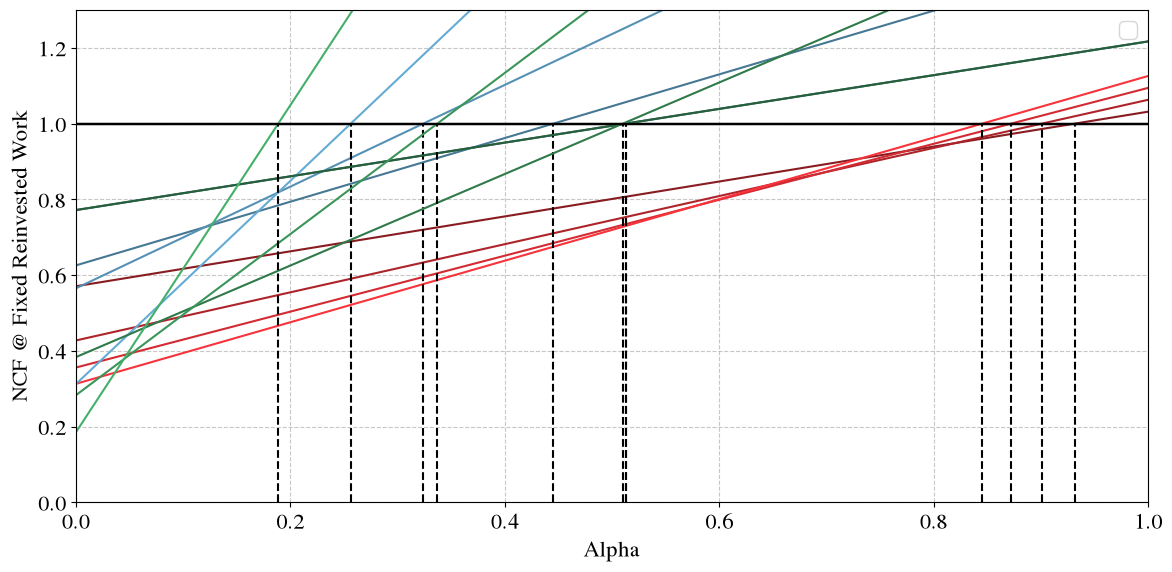

In [85]:
plot_soa = 1
plot_our = 0

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,1,figsize=(12, 6), sharey='row', squeeze=False)

for k in range(3):
    ax[0,0].set_xlabel('ALpha')
    ax[0,0].grid(True, which='both', linestyle='--', alpha=0.7)

    # Add our accelerator

    for a in range(len(baseline_area)):
        for d, j in enumerate(analysis_Mem_type):
            p = ax[0,0].plot(alpha_studied,   theor_ncf_res[:,a,k,0,d,0],   color = 'black' , linestyle ='-')
            p = ax[0,0].vlines(theor_crit_alpha [a,k,0,d,0], ymin=0, ymax=1,   color = 'black' , linestyle ='--')

        for i in range(1,arch_Dim):
            for d, j in enumerate(analysis_Mem_type):
                p = ax[0,0].plot(alpha_studied,   theor_ncf_res[:,a,k,i,d,0],   color = color_array[k,i] , linestyle ='-')
                p = ax[0,0].vlines(theor_crit_alpha [a,k,i,d,0], ymin=0, ymax=1,   color = 'black' , linestyle ='--')


    ax[0,0].hlines(y=1,xmin = 0, xmax=1, color= "black")
    ax[0,0].set_ylim([0,1.3])
    ax[0,0].set_xlim([0,1])
    ax[0,0].set_xlabel("Alpha")


ax[0,0].set_ylabel("NCF @ Fixed Reinvested Work")
ax[0,0].legend()

# Add legend
fig.tight_layout()
plt.show()



C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_33808\963008600.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0,0].legend()


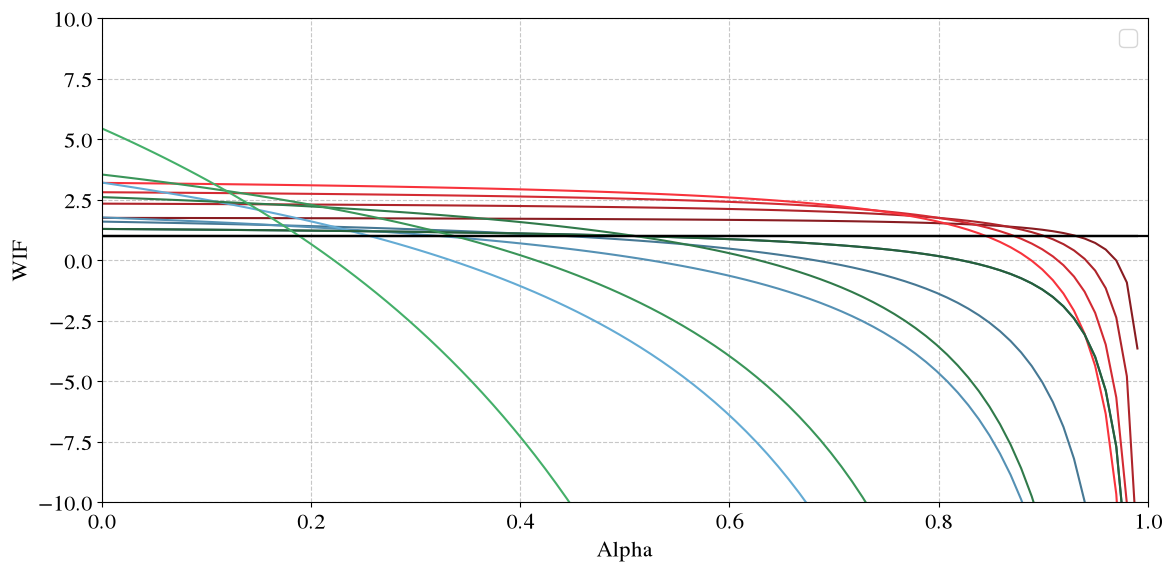

In [ ]:
plot_soa = 1
plot_our = 0

# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,1,figsize=(12, 6), sharey='row', squeeze=False)

for k in range(3):
    ax[0,0].set_xlabel('ALpha')
    ax[0,0].grid(True, which='both', linestyle='--', alpha=0.7)

    # Add our accelerator

    for a in range(len(baseline_area)):
        for d, j in enumerate(analysis_Mem_type):
            p = ax[0,0].plot(alpha_studied,   theor_ncf_test[:,a,k,0,d,0],   color = 'black' , linestyle ='-')
            
        for i in range(1,arch_Dim):
            for d, j in enumerate(analysis_Mem_type):
                p = ax[0,0].plot(alpha_studied,   theor_ncf_test[:,a,k,i,d,0],   color = color_array[k,i] , linestyle ='-')
                

    ax[0,0].hlines(y=1,xmin = 0, xmax=1, color= "black")
    ax[0,0].set_ylim([-10,10])
    ax[0,0].set_xlim([0,1])
    ax[0,0].set_xlabel("Alpha")


ax[0,0].set_ylabel("WIF")
ax[0,0].legend()

# Add legend
fig.tight_layout()
plt.show()



In [17]:
print(np.max(theor_asi_res))

nan


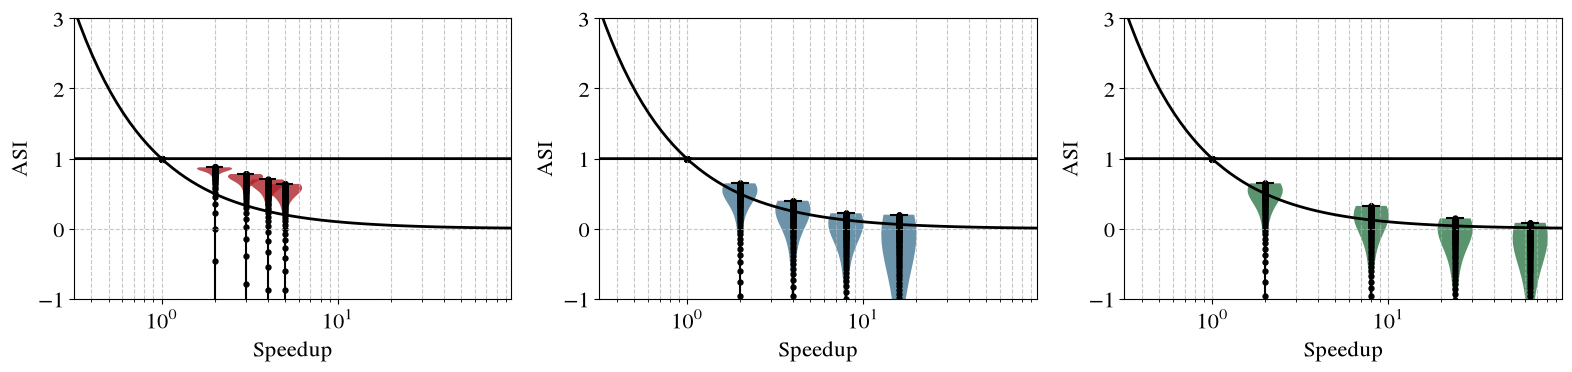

In [18]:
# ASI Framework separations
s_log_min = -0.5
s_log_max = 3
speedup_space = np.linspace(s_log_min, s_log_max, 100)

log_ticks = np.array([])
for i  in np.arange(np.floor(s_log_min), np.ceil(s_log_max),1) :
    log_ticks = np.append(log_ticks,i + np.log10(np.linspace(1,10, 10)))

sep_strongly_sustainable = 1/10**speedup_space
sep_weakly_sustainable   = 1/10**speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

arch_color_map = ['Reds', 'Blues', 'Greens']

alphaViolin=0.8
widthViolin=0.2
bwViolin   =0.1
# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(len(baseline_area),3,figsize=(16, 4*len(baseline_area)), squeeze=False)

formatter = FuncFormatter(lambda x_val, tick_pos: "$10^{{{:.0f}}}$".format(x_val))

for a in range(len(baseline_area)):
    for k in range(3):
        ax[a,k].set_ylabel('ASI')
        ax[a,k].plot(speedup_space, sep_strongly_sustainable, 'black', linewidth=2, label='Strongly Sustainable')
        ax[a,k].plot(speedup_space, sep_weakly_sustainable,   'black', linewidth=2, label='Weakly Sustainable')
        ax[a,k].set_xlabel('Speedup')
        ax[a,k].set_ylim([-1,3])#1.05*np.max(theor_asi_res)])
        ax[a,k].set_xlim([-0.5,1.1*np.log10(np.max(theor_speedup_ratio))])
        ax[a,k].grid(True, which='both', linestyle='--', alpha=0.7)
        ax[a,k].xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax[a,k].xaxis.set_major_formatter(formatter)
        ax[a,k].xaxis.set_minor_locator(ticker.FixedLocator(log_ticks))
    
    
    for k in range(3):

        for d, j in enumerate(analysis_Mem_type):
            asi_res_reshaped = np.reshape(theor_asi_res[:,a,k,:,:]            , (len(alpha_studied),(arch_Dim)*len(analysis_Mem_type)), copy=True)
            speedup_reshaped = np.reshape(theor_speedup_ratio[k,:,j],(                   (arch_Dim)*len(analysis_Mem_type)), copy=True)

            this_color_array = []
            this_color_array.append(('black',alphaViolin/2 ) )
            for i in range(1,arch_Dim):  
                this_color_array.append((color_array[k,2],alphaViolin ))
            
            vp1 = ax[a,k].violinplot(asi_res_reshaped, positions = np.log10(speedup_reshaped), widths=widthViolin, 
                                showmeans=False,showextrema=True,showmedians=False ,
                                facecolor=this_color_array,
                                bw_method=bwViolin, linecolor='black' , points=300)

            for i in range(0,arch_Dim):  
                p = ax[a,k].scatter(np.ones(len(alpha_studied))*np.log10(theor_speedup_ratio[k,i,j]),   np.maximum(theor_asi_res[:,a,k,i,d],-100),   c='black',  s=50, marker='.')

            

fig.tight_layout()
plt.show()

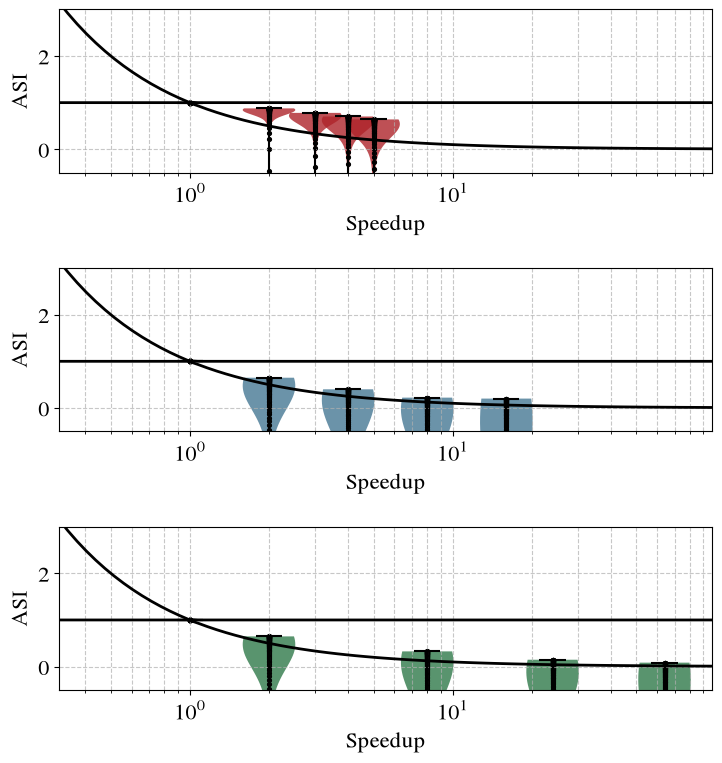

In [19]:
# ASI Framework separations
s_log_min = -0.5
s_log_max = 3
speedup_space = np.linspace(s_log_min, s_log_max, 100)

log_ticks = np.array([])
for i  in np.arange(np.floor(s_log_min), np.ceil(s_log_max),1) :
    log_ticks = np.append(log_ticks,i + np.log10(np.linspace(1,10, 10)))

sep_strongly_sustainable = 1/10**speedup_space
sep_weakly_sustainable   = 1/10**speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

arch_color_map = ['Reds', 'Blues', 'Greens']

alphaViolin=0.8
widthViolin=0.2
bwViolin   =0.3
# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(3,len(baseline_area),figsize=(7.5*len(baseline_area), 8), squeeze=False)

formatter = FuncFormatter(lambda x_val, tick_pos: "$10^{{{:.0f}}}$".format(x_val))

for a in range(len(baseline_area)):
    for k in range(3):
        ax[k,a].set_ylabel('ASI')
        ax[k,a].plot(speedup_space, sep_strongly_sustainable, 'black', linewidth=2, label='Strongly Sustainable')
        ax[k,a].plot(speedup_space, sep_weakly_sustainable,   'black', linewidth=2, label='Weakly Sustainable')
        ax[k,a].set_xlabel('Speedup')
        ax[k,a].set_ylim([-0.5,3]) #1.05*np.max(theor_asi_res)])
        ax[k,a].set_xlim([-0.5,1.1*np.log10(np.max(theor_speedup_ratio))])
        ax[k,a].grid(True, which='both', linestyle='--', alpha=0.7)
        ax[k,a].xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax[k,a].xaxis.set_major_formatter(formatter)
        ax[k,a].xaxis.set_minor_locator(ticker.FixedLocator(log_ticks))
    
    
    for k in range(3):

        for d, j in enumerate(analysis_Mem_type):
            asi_res_reshaped = np.reshape(theor_asi_res[:,a,k,:,:]            , (len(alpha_studied),(arch_Dim)*len(analysis_Mem_type)), copy=True)
            speedup_reshaped = np.reshape(theor_speedup_ratio[k,:,j],(                   (arch_Dim)*len(analysis_Mem_type)), copy=True)

            this_color_array = []
            this_color_array.append(('black',alphaViolin/2 ) )
            for i in range(1,arch_Dim):  
                this_color_array.append((color_array[k,2],alphaViolin ))
            
            vp1 = ax[k,a].violinplot(asi_res_reshaped, positions = np.log10(speedup_reshaped), widths=widthViolin, 
                                showmeans=False,showextrema=True,showmedians=False ,
                                facecolor=this_color_array,
                                bw_method=bwViolin, linecolor='black' , points=300)

            for i in range(0,arch_Dim):  
                p = ax[k,a].scatter(np.ones(len(alpha_studied))*np.log10(theor_speedup_ratio[k,i,j]),   np.maximum(theor_asi_res[:,a,k,i,d],-100),   
                c='black',  s=30, marker='.') 

fig.tight_layout()
plt.show()

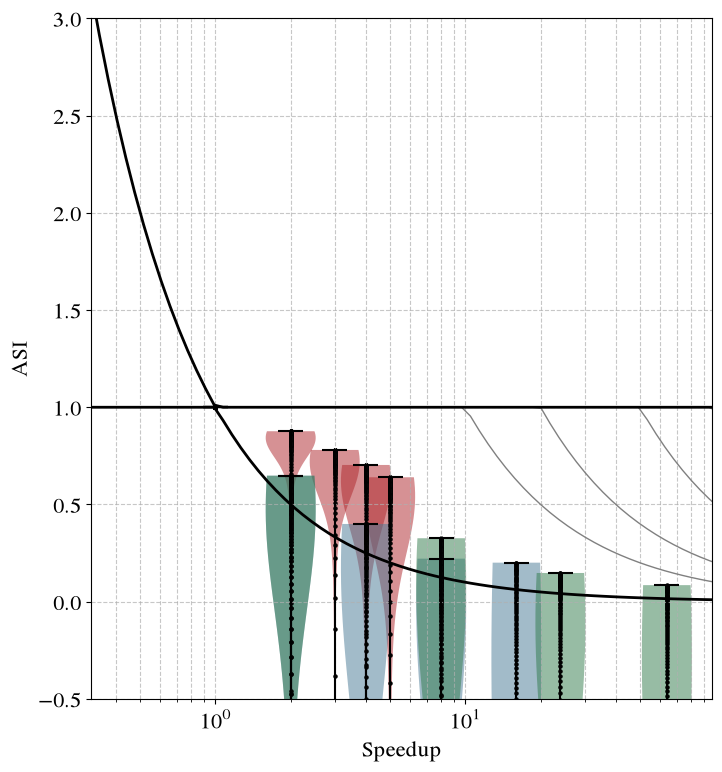

In [20]:
max_reused_speedup = np.array([10,20,50,100])

# ASI Framework separations
s_log_min = -0.5
s_log_max = 3
speedup_space = np.linspace(s_log_min, s_log_max, 100)

log_ticks = np.array([])
for i  in np.arange(np.floor(s_log_min), np.ceil(s_log_max),1) :
    log_ticks = np.append(log_ticks,i + np.log10(np.linspace(1,10, 10)))

formatter = FuncFormatter(lambda x_val, tick_pos: "$10^{{{:.0f}}}$".format(x_val))

sep_strongly_sustainable = 1/10**speedup_space
sep_weakly_sustainable   = 1/10**speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

arch_color_map = ['Reds', 'Blues', 'Greens']

alphaViolin=0.5
widthViolin=0.2
bwViolin   =0.3
# Plot the operation footprint vs FFT throughput

fig, ax = plt.subplots(1,len(baseline_area),figsize=(7.5*len(baseline_area), 8), squeeze=False)

for a in range(len(baseline_area)):
    ax[0,a].set_ylabel('ASI')
    for n, n_s_lim in enumerate(max_reused_speedup):
        new_speedup_limit        = 1/10**speedup_space
        new_speedup_limit  [np.where((10**speedup_space)>n_s_lim)]   = n_s_lim * new_speedup_limit  [np.where((10**speedup_space)>n_s_lim)]
        new_speedup_limit  [np.where((10**speedup_space)<=n_s_lim)]  = 1
        ax[0,a].plot(speedup_space, new_speedup_limit,   'gray', linewidth=1)

    ax[0,a].plot(speedup_space, sep_strongly_sustainable, 'black', linewidth=2, label='Strongly Sustainable')
    ax[0,a].plot(speedup_space, sep_weakly_sustainable,   'black', linewidth=2, label='Weakly Sustainable')
    ax[0,a].set_xlabel('Speedup')
    ax[0,a].set_ylim([-0.5,3])#1.05*np.max(theor_asi_res)])
    ax[0,a].set_xlim([-0.5,1.1*np.log10(np.max(theor_speedup_ratio))])
    ax[0,a].grid(True, which='both', linestyle='--', alpha=0.7)
    ax[0,a].xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax[0,a].xaxis.set_major_formatter(formatter)
    ax[0,a].xaxis.set_minor_locator(ticker.FixedLocator(log_ticks))
  
    for d, j in enumerate(analysis_Mem_type):
        asi_res_reshaped = np.reshape(theor_asi_res            , (len(alpha_studied),3*(arch_Dim)*len(analysis_Mem_type)), copy=True)
        speedup_reshaped = np.reshape(theor_speedup_ratio[:,:,j],(                   3*(arch_Dim)*len(analysis_Mem_type)), copy=True)

        this_color_array = []
        for k in range(3):
            this_color_array.append(('black',alphaViolin/3 ) )
            for i in range(1,arch_Dim):  
                this_color_array.append((color_array[k,2],alphaViolin ))
        
        vp1 = ax[0,a].violinplot(asi_res_reshaped, positions = np.log10(speedup_reshaped), widths=widthViolin, 
                            showmeans=False,showextrema=True,showmedians=False ,
                            facecolor=this_color_array,
                            bw_method=bwViolin, linecolor='black' , points=300)
        
        for k in range(3):
            for i in range(0,arch_Dim):  
                p = ax[0,a].scatter(np.ones(len(alpha_studied))*np.log10(theor_speedup_ratio[k,i,j]),   np.maximum(theor_asi_res[:,a,k,i,d],-100),   
                c='black',  s=20, marker='.')

            

#fig.colorbar(p,ax=ax,orientation='vertical',label='Alpha')

# Add legend
fig.tight_layout()
plt.show()


In [21]:

F_p_J_grid = 1.27e-07 #kgCO2/J
F_p_J_batt = 1.16e-05 #kgCO2/J

F_p_mm2 = 0.97/100


cases_array= np.array([
    # Area, Emb      Carbon In  Lifetime      fs
    [ 0.6 , F_p_mm2, F_p_J_grid,    10  ,      10**1 ],
    [ 0.6 , F_p_mm2, F_p_J_batt,    10  ,      10**1 ],
    [ 0.6 , F_p_mm2, F_p_J_grid,    10  ,      10**2 ],
    [ 0.6 , F_p_mm2, F_p_J_batt,    10  ,      10**2 ],
    [ 0.6 , F_p_mm2, F_p_J_grid,    10  ,      10**3 ],
    [ 0.6 , F_p_mm2, F_p_J_batt,    10  ,      10**3 ],
    [ 0.6 , F_p_mm2, F_p_J_grid,    10  ,      10**4 ],
    [ 0.6 , F_p_mm2, F_p_J_batt,    10  ,      10**4 ],
    [ 0.6 , F_p_mm2, F_p_J_grid,    10  ,      32e3 ],
    [ 0.6 , F_p_mm2, F_p_J_batt,    10  ,      32e3 ],
])
# Embodied

array_area     = cases_array[:,0]
array_F_p_mm2  = cases_array[:,1]
array_F_p_J    = cases_array[:,2]
array_lifetime = cases_array[:,3]
array_fs       = cases_array[:,4]

base_emb = array_F_p_mm2*array_area
base_op =  array_fs*array_F_p_J*(365*24*60*60*array_lifetime)*baseline_energy/nFFT
print("Alpha")
print((base_emb/(base_emb+base_op)))


Alpha
[0.99995303 0.9957282  0.99953053 0.95886353 0.99532501 0.69978381
 0.95513766 0.18903135 0.86933661 0.067896  ]


C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_33808\187303287.py:6: RuntimeWarning: invalid value encountered in divide
  theor_ncf_test[:,a,k,i,d,0]= (1 - (theor_area_ratio[k,i,j,a]* (alpha_studied)) ) /  (theor_energy_ratio[k,i,j]* (1-alpha_studied))
C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_33808\187303287.py:7: RuntimeWarning: invalid value encountered in divide
  theor_ncf_test[:,a,k,i,d,1]= (1 - (theor_area_ratio[k,i,j,a]* (alpha_studied)) ) /  (theor_energy_ratio[k,i,j]* (1-alpha_studied) *min(max_usable_speedup,theor_speedup_ratio[k,i,j]))
C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_33808\187303287.py:6: RuntimeWarning: divide by zero encountered in divide
  theor_ncf_test[:,a,k,i,d,0]= (1 - (theor_area_ratio[k,i,j,a]* (alpha_studied)) ) /  (theor_energy_ratio[k,i,j]* (1-alpha_studied))
C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_33808\187303287.py:7: RuntimeWarning: divide by zero encountered in divide
  theor_ncf_test[:,a,k,i,d,1]= (1 - (theor_area_rat

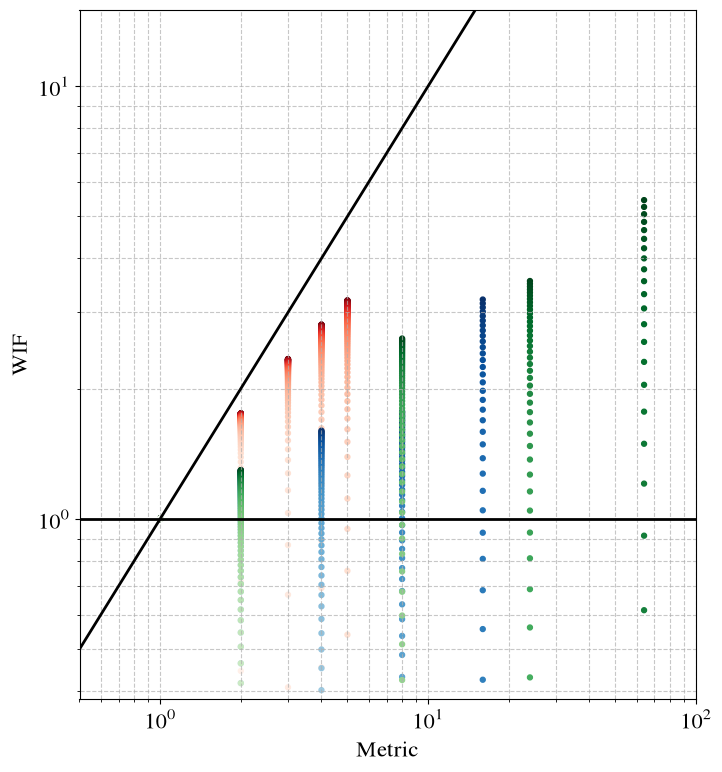

In [ ]:

# -----------------

# ASI Framework separations
speedup_space = np.linspace(0.5, 100, 100)


sep_strongly_sustainable = 1/speedup_space
sep_weakly_sustainable   = 1/speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

arch_color_map = ['Reds', 'Blues', 'Greens']

alphaViolin=0.5
widthViolin=0.2
bwViolin   =0.01
# Plot the operation footprint vs FFT throughput

fig, ax = plt.subplots(1,len(baseline_area),figsize=(7.5*len(baseline_area), 8), squeeze=False)

metric = theor_speedup_ratio # 1/theor_energy_ratio # 

metric_sust = theor_ncf_test[:,:,:,:,:,0]  # theor_asi_res[:,:,:,:,:] # 


arch_color_map = ['Reds', 'Blues', 'Greens']

for a in range(len(baseline_area)):
    ax[0,a].set_xscale('log')
    ax[0,a].set_yscale('log')
    ax[0,a].set_ylabel('WIF')

    ax[0,a].plot(speedup_space, speedup_space, 'black', linewidth=2, label='Strongly Sustainable')
    ax[0,a].plot(speedup_space, np.ones(len(speedup_space)), 'black', linewidth=2, label='Strongly Sustainable')
    ax[0,a].set_xlabel('Metric')

    ax[0,a].set_xlim([0.5,100])
    ax[0,a].set_ylim([-1 ,15])
    ax[0,a].grid(True, which='both', linestyle='--', alpha=0.7)
  
    for d, j in enumerate(analysis_Mem_type):
        #metric_sust_reshaped = np.reshape(metric_sust[:,a,:,:,:]  ,(len(alpha_studied),3*(arch_Dim)*len(analysis_Mem_type)), copy=True)
        #metric_reshaped      = np.reshape(metric[:,:,j]             ,(                      3*(arch_Dim)*len(analysis_Mem_type)), copy=True)
        #this_color_array = []
        #for k in range(3):
        #    this_color_array.append(('black',alphaViolin/3 ) )
        #    for i in range(1,arch_Dim):  
        #        this_color_array.append((color_array[k,2],alphaViolin ))
        #
        #vp1 = ax[0,a].violinplot(metric_sust_reshaped, positions = np.log10(metric_reshaped), widths=widthViolin, 
        #                    showmeans=False,showextrema=True,showmedians=False ,
        #                    facecolor=this_color_array,
        #                    bw_method=bwViolin, linecolor='black' , points=300)
        #
        
        for k in range(3):
            for i in range(0,arch_Dim):  
                #p = ax[0,a].scatter(np.ones(len(alpha_studied))*np.log10(metric[k,i,j]),   metric_sust[:,a,k,i,d], c='black',  s=20, marker='.')
                p = ax[0,a].scatter(np.ones(len(alpha_studied))*(metric[k,i,j]),   metric_sust[:,a,k,i,d], c=1-alpha_studied,cmap=arch_color_map[k],  s=50, marker='.')

            

#fig.colorbar(p,ax=ax,orientation='vertical',label='Alpha')

# Add legend
fig.tight_layout()
plt.show()


C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_33808\4253334455.py:6: RuntimeWarning: invalid value encountered in divide
  theor_ncf_test[:,a,k,i,d,0]= (1 - (theor_area_ratio[k,i,j,a]* (alpha_studied)) ) /  (theor_energy_ratio[k,i,j]* (1-alpha_studied))
C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_33808\4253334455.py:7: RuntimeWarning: invalid value encountered in divide
  theor_ncf_test[:,a,k,i,d,1]= (1 - (theor_area_ratio[k,i,j,a]* (alpha_studied)) ) /  (theor_energy_ratio[k,i,j]* (1-alpha_studied) *min(max_usable_speedup,theor_speedup_ratio[k,i,j]))
C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_33808\4253334455.py:6: RuntimeWarning: divide by zero encountered in divide
  theor_ncf_test[:,a,k,i,d,0]= (1 - (theor_area_ratio[k,i,j,a]* (alpha_studied)) ) /  (theor_energy_ratio[k,i,j]* (1-alpha_studied))
C:\Users\maistriauxp\AppData\Local\Temp\ipykernel_33808\4253334455.py:7: RuntimeWarning: divide by zero encountered in divide
  theor_ncf_test[:,a,k,i,d,1]= (1 - (theor_area

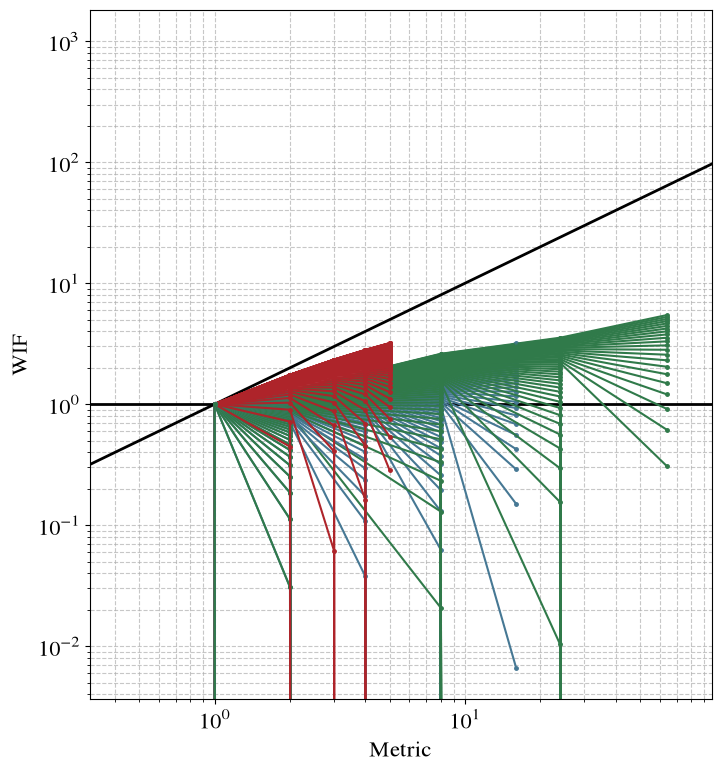

In [46]:

theor_ncf_test     = np.zeros((len(alpha_studied),len(baseline_area),3,arch_Dim,analysis_nMem_type,2))
for k in range(3):
    for a in range(len(baseline_area)):
        for i in range(arch_Dim):
            for d, j in enumerate(analysis_Mem_type):
                theor_ncf_test[:,a,k,i,d,0]= (1 - (theor_area_ratio[k,i,j,a]* (alpha_studied)) ) /  (theor_energy_ratio[k,i,j]* (1-alpha_studied))
                theor_ncf_test[:,a,k,i,d,1]= (1 - (theor_area_ratio[k,i,j,a]* (alpha_studied)) ) /  (theor_energy_ratio[k,i,j]* (1-alpha_studied) *min(max_usable_speedup,theor_speedup_ratio[k,i,j])) 
               
          
# -----------------
max_reused_speedup = np.array([10,20,50,100])

# ASI Framework separations
s_log_min = -0.5
s_log_max = 3
speedup_space = np.linspace(s_log_min, s_log_max, 100)

log_ticks = np.array([])
for i  in np.arange(np.floor(s_log_min), np.ceil(s_log_max),1) :
    log_ticks = np.append(log_ticks,i + np.log10(np.linspace(1,10, 10)))

formatter = FuncFormatter(lambda x_val, tick_pos: "$10^{{{:.0f}}}$".format(x_val))

sep_strongly_sustainable = 1/10**speedup_space
sep_weakly_sustainable   = 1/10**speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

arch_color_map = ['Reds', 'Blues', 'Greens']

alphaViolin=0.5
widthViolin=0.2
bwViolin   =0.3
# Plot the operation footprint vs FFT throughput

fig, ax = plt.subplots(1,len(baseline_area),figsize=(7.5*len(baseline_area), 8), squeeze=False)

metric = theor_speedup_ratio # 1/theor_energy_ratio # 

alpha_step = 1
metric_sust = theor_ncf_test[:,:,:,:,:,0] # theor_asi_res # 

for a in range(len(baseline_area)):
    ax[0,a].set_yscale('log')
    ax[0,a].set_ylabel('WIF')

    ax[0,a].plot(speedup_space, 10**speedup_space, 'black', linewidth=2, label='Strongly Sustainable')
    ax[0,a].plot(speedup_space, np.ones(len(speedup_space)), 'black', linewidth=2, label='Strongly Sustainable')
    ax[0,a].set_xlabel('Metric')

    ax[0,a].set_xlim([-0.5,1.1*np.max(np.log10(metric))])
    ax[0,a].grid(True, which='both', linestyle='--', alpha=0.7)
    ax[0,a].xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax[0,a].xaxis.set_major_formatter(formatter)
    ax[0,a].xaxis.set_minor_locator(ticker.FixedLocator(log_ticks))
  
    for d, j in enumerate(analysis_Mem_type):

        for i_a, alp  in enumerate(alpha_studied[::alpha_step]):
            for k in range(3):  
                p = ax[0,a].plot(np.log10(metric[k,:,j]),   metric_sust[i_a*alpha_step,a,k,:,d],  c=color_array[k,2],  markersize=5, marker='.')

            

#fig.colorbar(p,ax=ax,orientation='vertical',label='Alpha')

# Add legend
fig.tight_layout()
plt.show()


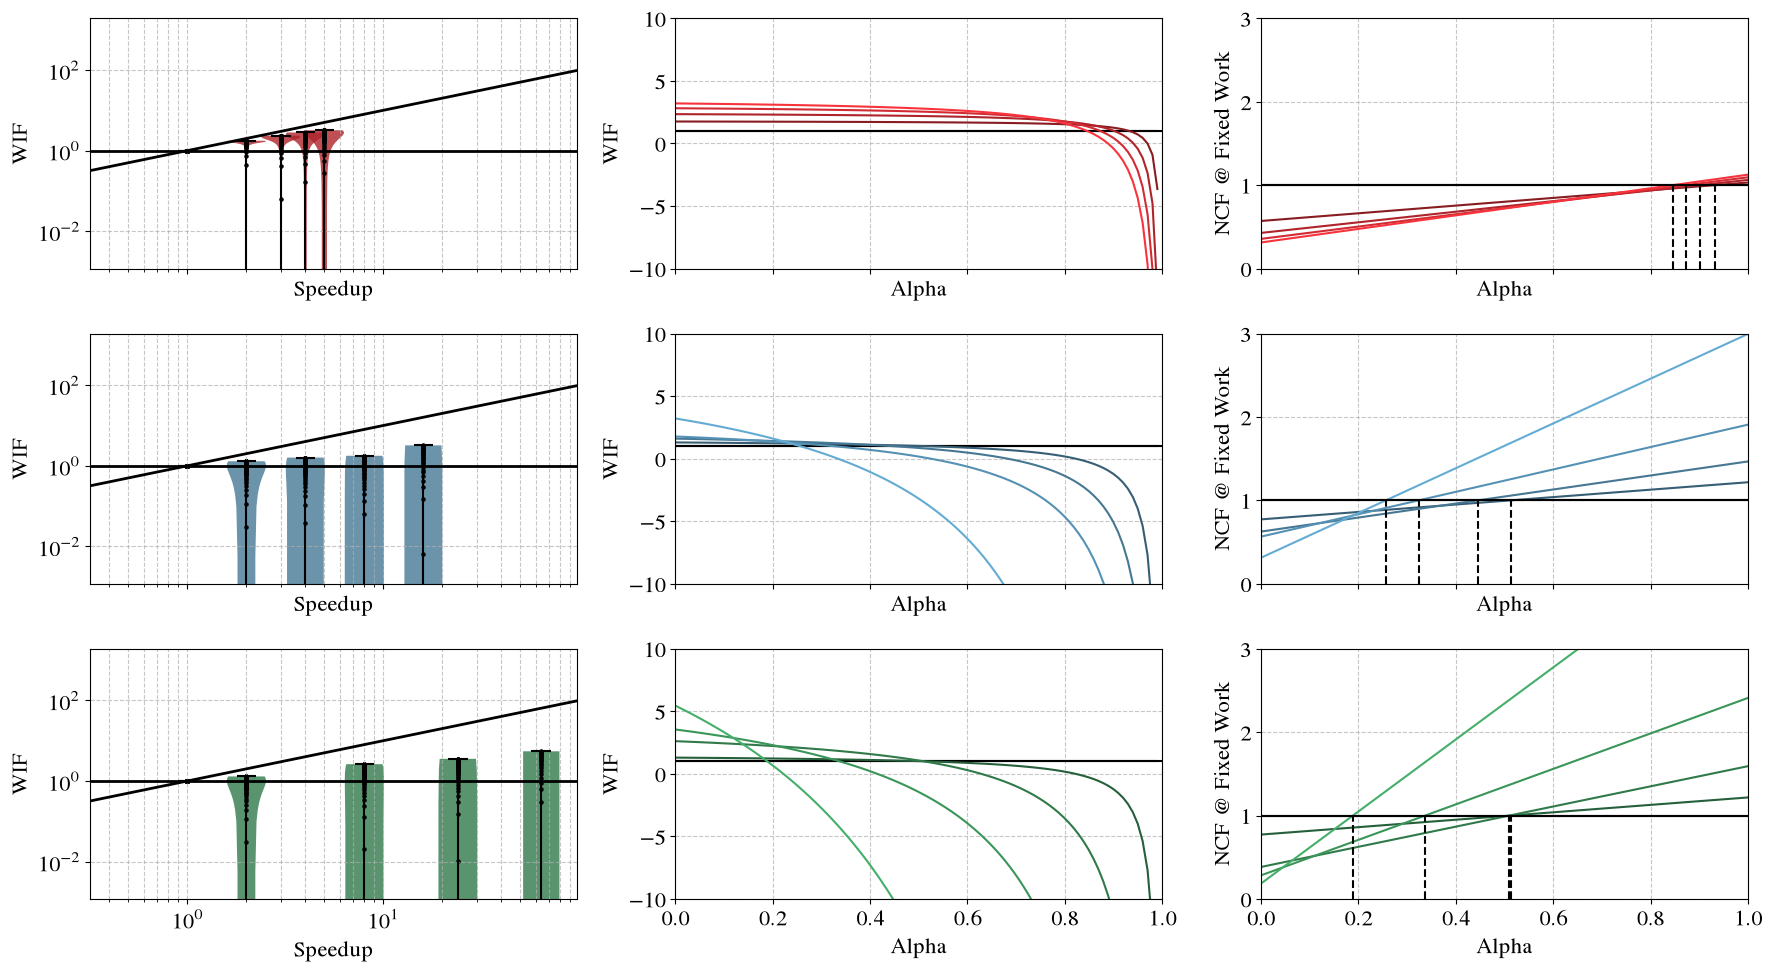

In [44]:
# ASI Framework separations
s_log_min = -0.5
s_log_max = 3
speedup_space = np.linspace(s_log_min, s_log_max, 100)

log_ticks = np.array([])
for i  in np.arange(np.floor(s_log_min), np.ceil(s_log_max),1) :
    log_ticks = np.append(log_ticks,i + np.log10(np.linspace(1,10, 10)))

sep_strongly_sustainable = 1/10**speedup_space
sep_weakly_sustainable   = 1/10**speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

arch_color_map = ['Reds', 'Blues', 'Greens']

alphaViolin=0.8
widthViolin=0.2
bwViolin   =0.2
# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(3,3,figsize=(18, 10), squeeze=False,sharey='col',sharex='col')

formatter = FuncFormatter(lambda x_val, tick_pos: "$10^{{{:.0f}}}$".format(x_val))

#########################################################################################
metric= (theor_speedup_ratio) #/  theor_speedup_ratio #1/theor_energy_ratio
for k in range(3):
    ax[k,0].set_yscale('log')
    ax[k,0].set_ylabel('WIF')
    ax[k,0].plot(speedup_space, 10**speedup_space, 'black', linewidth=2, label='Strongly Sustainable')
    ax[k,0].plot(speedup_space, np.ones(len(speedup_space)), 'black', linewidth=2, label='Strongly Sustainable')
    ax[k,0].set_xlabel('Speedup')
    ax[k,0].set_xlim([-0.5,1.1*np.log10(np.max(theor_speedup_ratio))])
    #ax[k,0].set_ylim([-2,1.1*np.max(theor_ncf_test)])
    ax[k,0].grid(True, which='both', linestyle='--', alpha=0.7)
    ax[k,0].xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax[k,0].xaxis.set_major_formatter(formatter)
    ax[k,0].xaxis.set_minor_locator(ticker.FixedLocator(log_ticks))
    for a in range(len(baseline_area)):
        for d, j in enumerate(analysis_Mem_type):

            asi_res_reshaped = np.reshape(theor_ncf_test[:,a,k,:,:,0]  ,(len(alpha_studied),(arch_Dim)*len(analysis_Mem_type)), copy=True)
            speedup_reshaped = np.reshape(metric[k,:,j],(                      (arch_Dim)*len(analysis_Mem_type)), copy=True)

            this_color_array = []
            this_color_array.append(('black',alphaViolin/2 ) )
            for i in range(1,arch_Dim):  
                this_color_array.append((color_array[k,2],alphaViolin ))
        
        vp1 = ax[k,0].violinplot(asi_res_reshaped, positions = np.log10(speedup_reshaped), widths=widthViolin, 
                            showmeans=False,showextrema=True,showmedians=False ,
                            facecolor=this_color_array,
                            bw_method=bwViolin, linecolor='black' , points=300)
        
for k in range(3):
    for i in range(0,arch_Dim): 
        p = ax[k,0].scatter(np.ones(len(alpha_studied))*np.log10(metric[k,i,j]),   theor_ncf_test[:,a,k,i,d,0],   
        c='black',  s=20, marker='.')

#########################################################################################
for k in range(3):
    #ax[k,1].set_yscale('log')
    ax[k,1].set_ylabel('WIF')
    ax[k,1].set_xlabel('Alpha')
    ax[k,1].set_ylim([-10,10])#1.1*np.max(theor_ncf_test)])
    ax[k,1].set_xlim([0,1])
    ax[k,1].grid(True, which='both', linestyle='--', alpha=0.7)

    p = ax[k,1].hlines(1, xmin=0, xmax=1,   color = 'black' , linestyle ='-')

    metric_sust = theor_ncf_test[:,:,:,:,:,0] # theor_asi_res # 
    for d, j in enumerate(analysis_Mem_type):

        for a in range(len(baseline_area)):
            p = ax[k,1].plot(alpha_studied, metric_sust[:,a,k,0,d],  c='black')#, marker='.')
            for i in range(1,arch_Dim):  
                p = ax[k,1].plot(alpha_studied, metric_sust[:,a,k,i,d],  c=color_array[k,i])#, marker='.')
#########################################################################################
for k in range(3):
    ax[k,2].set_xlabel('ALpha')
    ax[k,2].grid(True, which='both', linestyle='--', alpha=0.7)

    # Add our accelerator
    for a in range(len(baseline_area)):
        for d, j in enumerate(analysis_Mem_type):
            p = ax[k,2].plot(alpha_studied,   theor_ncf_res[:,a,k,0,d,0],   color = 'black' , linestyle ='-')
            p = ax[k,2].vlines(theor_crit_alpha [a,k,0,d,0], ymin=0, ymax=1,   color = 'black' , linestyle ='--')

        for i in range(1,arch_Dim):
            for d, j in enumerate(analysis_Mem_type):
                p = ax[k,2].plot(alpha_studied,   theor_ncf_res[:,a,k,i,d,0],   color = color_array[k,i] , linestyle ='-')
                p = ax[k,2].vlines(theor_crit_alpha [a,k,i,d,0], ymin=0, ymax=1,   color = 'black' , linestyle ='--')

    ax[k,2].hlines(y=1,xmin = 0, xmax=1, color= "black")
    ax[k,2].set_xlim([0,1])
    ax[k,2].set_ylim([0,3])
    ax[k,2].set_xlabel("Alpha")
    ax[k,2].set_ylabel("NCF @ Fixed Work")

#########################################################################################

fig.tight_layout()
plt.show()

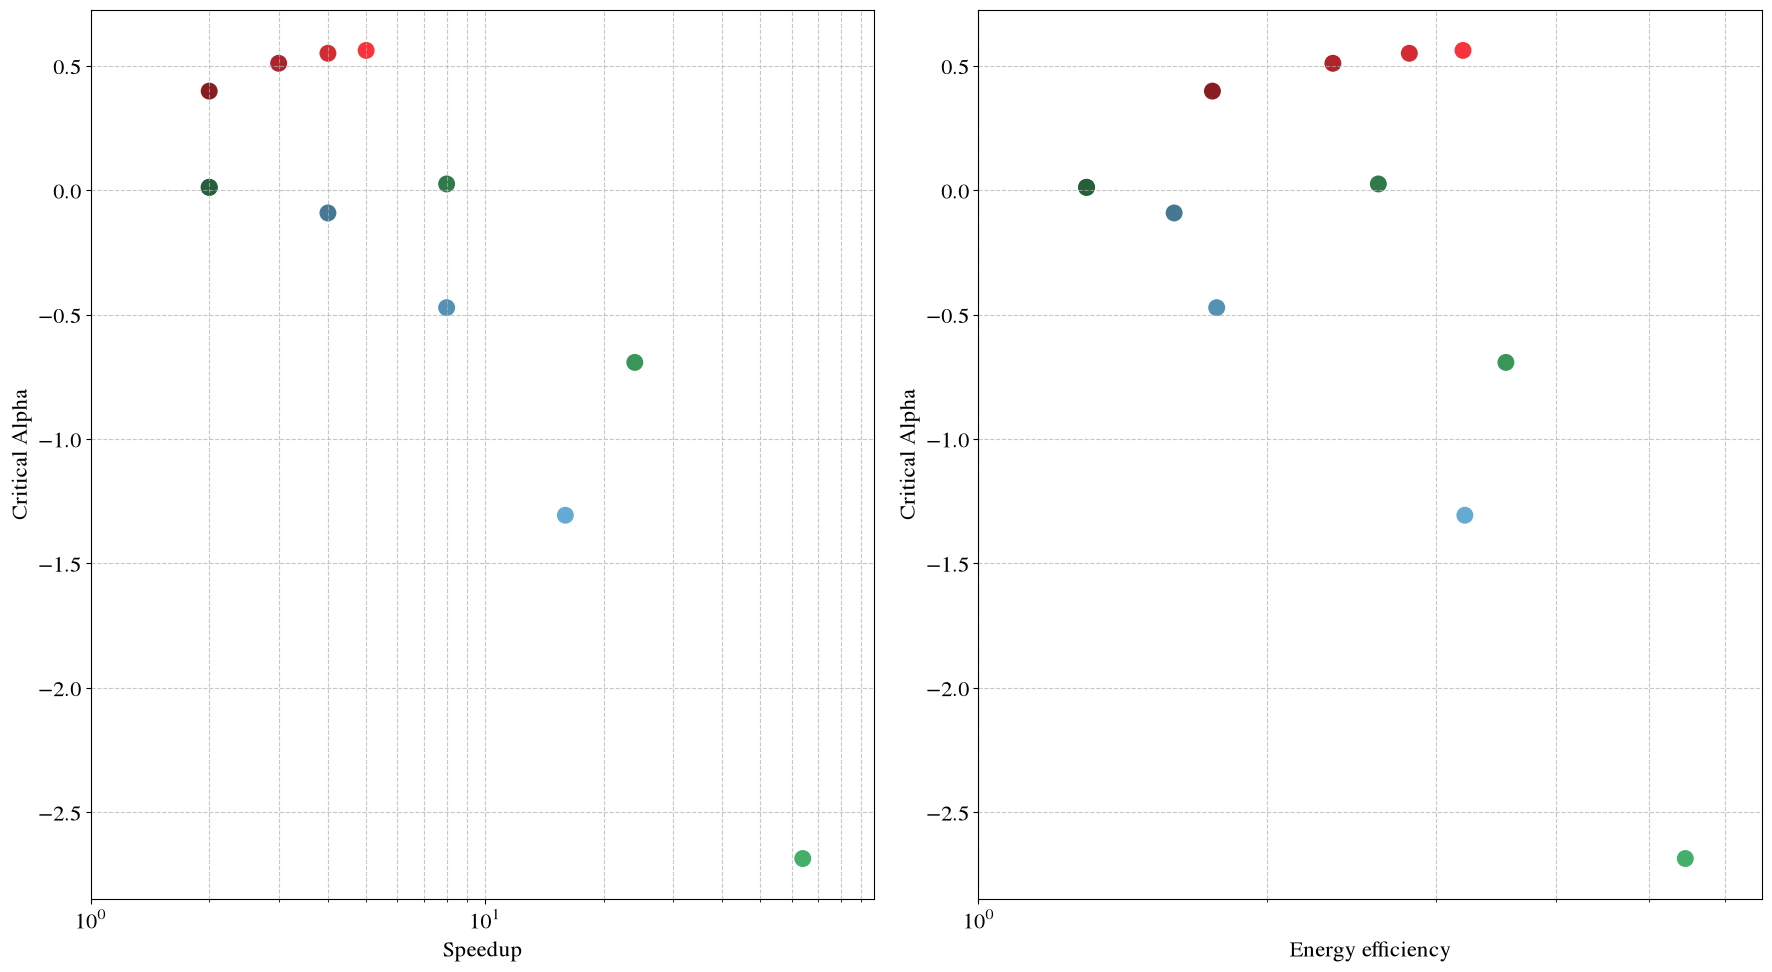

In [66]:
# ASI Framework separations
s_log_min = -0.5
s_log_max = 3
speedup_space = np.linspace(s_log_min, s_log_max, 100)

log_ticks = np.array([])
for i  in np.arange(np.floor(s_log_min), np.ceil(s_log_max),1) :
    log_ticks = np.append(log_ticks,i + np.log10(np.linspace(1,10, 10)))

sep_strongly_sustainable = 1/10**speedup_space
sep_weakly_sustainable   = 1/10**speedup_space

sep_strongly_sustainable[np.where(sep_strongly_sustainable<1)] =1
sep_weakly_sustainable  [np.where(sep_weakly_sustainable>1)]   =1

arch_color_map = ['Reds', 'Blues', 'Greens']

alphaViolin=0.8
widthViolin=0.2
bwViolin   =0.5
# Plot the operation footprint vs FFT throughput
fig, ax = plt.subplots(1,2,figsize=(18, 10), squeeze=False,sharey='col',sharex='col')

formatter = FuncFormatter(lambda x_val, tick_pos: "$10^{{{:.0f}}}$".format(x_val))

#########################################################################################
for i in range(2):
    ax[0,i].set_yscale('linear')
    ax[0,i].set_ylabel('Critical Alpha')
    ax[0,i].grid(True, which='both', linestyle='--', alpha=0.7)
    ax[0,i].xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax[0,i].xaxis.set_major_formatter(formatter)
    ax[0,i].xaxis.set_minor_locator(ticker.FixedLocator(log_ticks))

ax[0,0].set_xlim([0,1.1*np.log10(np.max(theor_speedup_ratio))])
ax[0,1].set_xlim([0,1.1*np.log10(np.max(1/theor_energy_ratio))])

#ax[0,0].set_ylim([np.min(theor_crit_alpha[:,:,:,:,0])/1.05,1])
#ax[0,1].set_ylim([np.min(theor_crit_alpha[:,:,:,:,0])/1.05,1])

ax[0,0].set_xlabel('Speedup')
ax[0,1].set_xlabel('Energy efficiency')


#########################################################################################
for k in range(3):
    for a in range(len(baseline_area)):
        for d, j in enumerate(analysis_Mem_type): 

            metric = ((1-theor_energy_ratio[k,:,j])*theor_crit_alpha [a,k,:,d,0]) / ((1-theor_crit_alpha [a,k,:,d,0])*(theor_area_ratio[k,:,j,a]-1))
            metric = theor_crit_alpha [a,k,:,d,0]
            metric = ((1-theor_energy_ratio[k,:,j])*theor_crit_alpha [a,k,:,d,0]) - ((1-theor_crit_alpha [a,k,:,d,0])*(theor_area_ratio[k,:,j,a]-1))
            
            ax[0,0].scatter(np.log10(theor_speedup_ratio[k,:,j]), metric           , color=color_array[k,:arch_Dim] , marker = '.',s=500)#markersize= 30)
            ax[0,0].scatter(np.log10(theor_speedup_ratio[0,0,j]), metric[0]        , color='black'                  , marker = '.',s=500)#markersize= 30)
            ax[0,1].scatter(np.log10(1/theor_energy_ratio[k,:,j]), metric          , color=color_array[k,:arch_Dim] , marker = '.',s=500)#markersize= 30)
            ax[0,1].scatter(np.log10(1/theor_energy_ratio[0,0,j]), metric[0]       , color='black'                  , marker = '.',s=500)#markersize= 30)

#########################################################################################

fig.tight_layout()
plt.show()